# Stochastic Neighbor Embedding — Academic Summary

# https://www.cs.toronto.edu/~hinton/absps/sne.pdf

## Abstract
This paper introduces **Stochastic Neighbor Embedding (SNE)**, a probabilistic method for embedding high-dimensional objects—represented either as vectors or pairwise dissimilarities—into a low-dimensional space while preserving neighbor identity. SNE centers a Gaussian on each high-dimensional point to define a probability distribution over potential neighbors, and seeks a low-dimensional configuration that induces a matching neighbor distribution. The embedding is optimized by minimizing a sum of Kullback-Leibler divergences via gradient descent. Unlike prior dimensionality reduction methods that assign each object a single fixed low-dimensional location, SNE's probabilistic formulation naturally extends to a **mixture model**, allowing ambiguous objects (e.g., the word "bank") to be represented by multiple, widely separated low-dimensional images without forcing unrelated concepts together.

## Problems
- Existing dimensionality reduction methods (MDS, Isomap, PCA, LLE, SOM/GTM) associate each high-dimensional object with only a **single** location in the low-dimensional space.
- This single-location constraint makes it difficult to represent **many-to-one** or ambiguous mappings, where an object (e.g., a polysemous word) genuinely belongs near several disparate low-dimensional regions.
- Methods emphasizing local geometry preservation (e.g., LLE, SOM) can allow widely separated high-dimensional points to be incorrectly "collapsed" together as near neighbors in the low-dimensional map.
- PCA and similar variance-maximizing linear projections prioritize large-scale separations, which can cause boundaries between similar classes to become jumbled.

## Proposed Solutions
1. **Probabilistic Neighbor Definition (High-Dimensional Space)**: Convert pairwise (dis)similarities into an asymmetric probability that object $i$ would pick object $j$ as its neighbor:
$$p_{ij} = \frac{\exp(-d_{ij}^2)}{\sum_{k \neq i}\exp(-d_{ik}^2)}, \qquad d_{ij}^2 = \frac{\|x_i - x_j\|^2}{2\sigma_i^2}$$
where $\sigma_i$ is chosen (by hand or via binary search) so the neighbor distribution's entropy equals $\log k$, with $k$ the desired "perplexity" (effective number of neighbors).

2. **Probabilistic Neighbor Definition (Low-Dimensional Space)**: Use a fixed-variance Gaussian (variance $=\tfrac{1}{2}$) around each low-dimensional image $y_i$ to induce an analogous probability:
$$q_{ij} = \frac{\exp(-\|y_i-y_j\|^2)}{\sum_{k \neq i}\exp(-\|y_i-y_k\|^2)}$$

3. **KL-Divergence Cost Function**: Minimize the sum, over all objects, of the KL divergence between the high-dimensional neighbor distribution $P_i$ and the induced low-dimensional distribution $Q_i$:
$$C = \sum_i \sum_j p_{ij}\log\frac{p_{ij}}{q_{ij}} = \sum_i KL(P_i\|Q_i)$$
This asymmetric cost penalizes representing near high-dimensional neighbors as distant more heavily than the reverse, preventing the "collapsing" problem seen in LLE/SOM.

4. **Gradient-Based Optimization**: Despite the complexity introduced by the normalization term in $q_{ij}$, the gradient has a simple "push-pull" form:
$$\frac{\partial C}{\partial y_i} = 2\sum_j (y_i-y_j)(p_{ij}-q_{ij}+p_{ji}-q_{ji})$$
interpreted as forces pulling $y_i$ toward under-selected neighbors and pushing it away from over-selected ones.

5. **Mixture Extension**: Generalize SNE so each object $i$ has multiple low-dimensional "image-versions" $y_{i_b}$ with mixing proportions $\pi_{i_b}$ summing to 1, allowing ambiguous objects to occupy multiple disparate regions simultaneously:
$$q_{ij} = \sum_b \pi_{i_b}\sum_c \frac{\pi_{j_c}\exp(-\|y_{i_b}-y_{j_c}\|^2)}{\sum_k\sum_d \pi_{k_d}\exp(-\|y_{i_b}-y_{k_d}\|^2)}$$

## Purpose
The purpose of the paper is to introduce a fundamentally new, probabilistic notion of embedding—based on stochastically selected neighbors rather than fixed geometric placement—that (1) faithfully preserves local neighborhood structure when reducing dimensionality for visualization or preprocessing, and (2) naturally supports representing a single ambiguous object via multiple, widely separated low-dimensional locations, which fixed-location methods cannot achieve.

## Methodology
- **Optimization procedure**: Embeddings are initialized by placing all $y_i$ at random locations very close to the origin, then trained via batch gradient descent (steepest descent) with **annealed jitter**—Gaussian noise added after each position update, with its standard deviation gradually reduced to zero—to help escape poor local optima.
- **Datasets and experiments**:
  - **Handwritten digits**: 3,000 grayscale bitmaps (256-dimensional) from the USPS database, 600 examples each from digit classes 0–4. Gaussian variance set to achieve perplexity $k=15$. Learning rate 0.2; jitter standard deviation 0.3 for the first 3,500 iterations, then reduced to 0 for a further 500 iterations. Compared against PCA on the same data.
  - **NIPS author-word data**: Word-author count matrices from OCRed NIPS proceedings (volumes 0–12), vocabulary size 13,649 words (after stopword removal, words occurring in ≥6 documents). Dissimilarities computed as the norm of differences between log aggregate author word counts (co-authored papers split fractionally). Local perplexity set to $k=25$; embedding of 676 authors who published more than one paper.
  - **Mixture-model proof-of-concept**: A dataset of 300 images each of digits 2, 3, and 4, plus 100 synthetic "hybrid" digit images constructed by randomly mixing pixels from two parent classes. Each object represented by exactly two mixture components (fixed mixing proportion 0.5), pulled together by a force capped beyond a threshold separation (threshold 0.05, force 0.025 nats/unit length at threshold). Perplexity of 10; step size 0.7 times the gradient; constant jitter of 0.05.
- **Evaluation approach**: Primarily qualitative visualization of 2D embeddings, supplemented by direct comparison of the SNE cost function value against the cost under a uniform neighbor distribution, and by measuring how often mixture components for hybrid vs. non-hybrid digits diverge to distinct locations.

## Results
- On the digit dataset, SNE cleanly separated the five digit classes in two dimensions **without any label information**, and within each class arranged the data so that orientation, skew, and stroke-thickness varied smoothly. The final SNE cost was 6,719 nats, substantially below the 15,894-nat cost of a uniform neighbor distribution over 3,000 points. PCA on the same data failed to separate classes as cleanly, since it prioritizes large-scale variance over local class boundaries.
- On the NIPS author-word data, the resulting 2D map organized the 676 authors into visually distinguishable, broadly coherent regions corresponding to major NIPS subfields (generative models, support vector machines, neuroscience, reinforcement learning, VLSI).
- In the mixture-model hybrid-digit experiment, after optimization **66% of hybrid images** had their two mixture components move to significantly different locations, versus only **19% of non-hybrid images**—and the mixture components of hybrids consistently landed in the regions corresponding to their two true parent classes, never in the third, unrelated class's region.
- The mixture version was also shown capable of unfolding a circle into a line without losing or introducing neighbor relationships, by mapping points near a "cut" to two separated mixture components—illustrating the method's capacity for handling topologically nontrivial many-to-one mappings.
- Practical optimization remained slow (several hours for 3,000 points using steepest descent with annealed jitter), motivating discussion of sparsification strategies (ignoring near-zero probability pairs, geometric data structures such as K-D/ball/AD-trees) and alternative search strategies (mixture "probability wormholes," penalized extra dimensions).

## Conclusions
- SNE demonstrates that framing dimensionality reduction as matching probabilistic neighbor distributions—rather than directly preserving distances—yields embeddings that both keep true neighbors close and keep dissimilar objects meaningfully separated, avoiding the "collapsing" failure mode of methods like LLE and SOM.
- The probabilistic formulation is uniquely suited to representing ambiguous, multi-sense objects via mixtures of widely separated images, a capability absent from single-location embedding methods; this is empirically validated by the hybrid-digit experiment.
- In the high-variance limit, SNE is shown to reduce to a form of mismatch minimization between antigeometric-mean-normalized squared distances, connecting it conceptually to nonmetric MDS "stress" functions.
- SNE is also framed as a degenerate special case of Linear Relational Embedding, restricted to a single "near" relationship represented by the identity matrix.
- The authors identify optimization efficiency as the primary open challenge, noting that steepest descent with annealed jitter—while effective—is computationally slow, and outline several directions (sparsification via fixed $P$, mixture-based "probability wormholes," and penalized extra dimensions) for future improvement. This work directly motivates later extensions such as t-SNE, which builds on SNE's probabilistic framework while addressing its optimization and crowding limitations.

# Mathematical and Statistical Content of "Stochastic Neighbor Embedding"

## 1. Asymmetric Neighbor Probability (High-Dimensional Space)
$$p_{ij} = \frac{\exp(-d_{ij}^2)}{\sum_{k \neq i} \exp(-d_{ik}^2)}$$
**Meaning**: Converts a dissimilarity $d_{ij}^2$ between objects $i$ and $j$ into a probability that object $i$ would "pick" object $j$ as its neighbor. This is asymmetric — $p_{ij} \neq p_{ji}$ in general — because the normalization is taken over all other neighbors of $i$ specifically. It reframes the embedding problem in terms of probable neighbor relationships rather than raw geometric distances.

## 2. Scaled Squared Euclidean Distance ("Affinity")
$$d_{ij}^2 = \frac{\|x_i - x_j\|^2}{2\sigma_i^2}$$
**Meaning**: When dissimilarities aren't given directly, this converts raw Euclidean distance between high-dimensional points $x_i, x_j$ into the input for the neighbor probability above. The per-point bandwidth $\sigma_i$ controls how "wide" the Gaussian neighborhood around point $i$ is — a small $\sigma_i$ means only very close points count as likely neighbors.

## 3. Perplexity-Based Bandwidth Selection
**Meaning**: Rather than manually fixing all $\sigma_i$ to the same value, each $\sigma_i$ is chosen individually via **binary search** so that the entropy of the resulting neighbor distribution equals $\log k$, where $k$ is a user-chosen "perplexity" representing the effective number of local neighbors. This adapts the neighborhood size to the local density of the data — dense regions get smaller $\sigma_i$, sparse regions get larger $\sigma_i$ — a key idea later reused and formalized in t-SNE.

## 4. Induced Low-Dimensional Neighbor Probability
$$q_{ij} = \frac{\exp(-\|y_i - y_j\|^2)}{\sum_{k \neq i}\exp(-\|y_i - y_k\|^2)}$$
**Meaning**: The low-dimensional analogue of $p_{ij}$, computed using a Gaussian with a **fixed** variance ($\tfrac{1}{2}$, chosen without loss of generality) centered on each map point $y_i$. The goal of the whole method is to arrange the $y_i$ so that $q_{ij}$ matches $p_{ij}$ as closely as possible.

## 5. Kullback-Leibler (KL) Divergence Cost Function
$$C = \sum_i \sum_j p_{ij}\log\frac{p_{ij}}{q_{ij}} = \sum_i KL(P_i \| Q_i)$$
**Meaning**: The total cost is a sum, over every object $i$, of the KL divergence between its true high-dimensional neighbor distribution $P_i$ and its induced low-dimensional neighbor distribution $Q_i$. Because KL divergence is asymmetric, making $q_{ij}$ large when $p_{ij}$ is small (i.e., placing unrelated points close together) is penalized, but doing the reverse (placing related points somewhat far apart) is penalized less — this asymmetry is what prevents distinct clusters from being incorrectly merged, unlike in LLE or SOM.

## 6. Gradient of the SNE Cost Function
$$\frac{\partial C}{\partial y_i} = 2\sum_j (y_i - y_j)(p_{ij} - q_{ij} + p_{ji} - q_{ji})$$
**Meaning**: Despite the complexity of differentiating through the normalization constant in $q_{ij}$, the result is a simple, interpretable "push-pull" force: each other point $y_j$ either pulls $y_i$ closer (if $i$ under-selects $j$ as a neighbor relative to the target) or pushes it away (if $i$ over-selects $j$). This gradient drives the iterative optimization of the embedding.

## 7. Optimization via Steepest Descent with Annealed Jitter
**Meaning**: A statistical/optimization technique where random Gaussian noise ("jitter") is added to each point's position after every gradient update, with the noise's standard deviation gradually decreased to zero over training. This is a form of simulated annealing that helps the optimization escape poor local minima, since pure steepest descent on all points in parallel is prone to getting stuck. Embeddings are initialized with all points placed randomly very close to the origin.

## 8. Empirical Cost Comparison Against a Uniform Baseline
**Meaning**: To judge whether a learned embedding is meaningfully better than chance, the paper compares the achieved SNE cost (6,719 nats for the digit experiment) against the cost that would result from a uniform distribution over all $n-1$ possible neighbors:
$$C_{\text{uniform}} = n\log_e\left(\frac{n-1}{k}\right)$$
For $n=3000$, $k=15$: $3000\log_e(2999/15) = 15{,}894$ nats. This is a simple statistical sanity check showing the optimized embedding captures substantially more structure than a random/uniform neighbor assignment would.

## 9. Mixture Model Extension of the Low-Dimensional Distribution
$$q_{ij} = \sum_b \pi_{i_b}\sum_c \frac{\pi_{j_c}\exp(-\|y_{i_b} - y_{j_c}\|^2)}{\sum_k\sum_d \pi_{k_d}\exp(-\|y_{i_b}-y_{k_d}\|^2)}$$
**Meaning**: Generalizes the model so each object $i$ can have multiple low-dimensional "versions" $y_{i_b}$, each with a mixing proportion $\pi_{i_b}$ (proportions across versions of the same object sum to 1). The induced neighbor probability becomes a weighted mixture over all version-pairs, allowing one high-dimensional object (e.g., an ambiguous word) to effectively occupy several distinct locations in the map simultaneously.

## 10. Auxiliary Probability Over Mixture Versions
$$r_{i_b j_c} = \frac{\pi_{j_c}\exp(-\|y_{i_b}-y_{j_c}\|^2)}{\sum_k\sum_d \pi_{k_d}\exp(-\|y_{i_b}-y_{k_d}\|^2)}$$
**Meaning**: Represents the probability that version $b$ of object $i$ selects version $c$ of object $j$ specifically (rather than any version of $j$ in aggregate). This intermediate quantity is used to derive the gradients needed to update both the mixture-component positions and their mixing proportions.

## 11. Gradient of $q_{ij}$ with Respect to Mixing Proportions
$$\frac{\partial q_{ij}}{\partial \pi_{m_g}} = \delta_{mi}\sum_c r_{m_g j_c} + \sum_b \frac{\pi_{i_b}}{\pi_{m_g}} r_{i_b m_g}\left[\delta_{mj} - \sum_c r_{i_b j_c}\right]$$
**Meaning**: A derivative used to determine how changing one object's mixing proportion $\pi_{m_g}$ affects the induced probability $q_{ij}$ for any pair $(i,j)$. The indicator $\delta_{mi}$ (1 if $m=i$, else 0) tracks whether the perturbed object matches $i$ or $j$ directly. This feeds into the overall cost gradient below.

## 12. Gradient of the Cost with Respect to Mixing Proportions
$$\frac{\partial C}{\partial \pi_{m_g}} = -\sum_i \sum_j \frac{p_{ij}}{q_{ij}} \frac{\partial q_{ij}}{\partial \pi_{m_g}}$$
**Meaning**: The chain-rule expression showing how the overall KL-divergence cost changes as a mixing proportion is adjusted, enabling gradient-based learning of not just positions but also how much "weight" each version of an ambiguous object should carry.

## 13. Softmax Reparameterization of Mixing Proportions
$$\pi_{i_b} = \frac{\exp(w_{i_b})}{\sum_f \exp(w_{i_f})}$$
**Meaning**: Since mixing proportions must be non-negative and sum to 1 (a constrained optimization problem), the paper instead optimizes unconstrained "softmax weights" $w_{i_b}$ and converts them to valid proportions via the softmax function — a standard statistical technique for turning constrained probability optimization into unconstrained optimization.

## 14. Threshold-Capped Attractive Force (Mixture Proof-of-Concept)
**Meaning**: In the simplified two-component mixture experiment, the force pulling the two components of one object together increases linearly with their separation up to a fixed threshold (0.05), beyond which the force plateaus at a constant value (0.025 nats per unit length). This prevents the optimization from being dominated by extreme separations and allows genuinely ambiguous (hybrid) objects to keep their two components far apart when warranted.

## 15. High-Variance Limit: SNE as Distance-Mismatch Minimization
$$\text{Mismatch} = \sum_{ij}\left[(d_{ij}^2 - g_i^2) - (\hat d_{ij}^2 - \hat g_i^2)\right]^2$$
with
$$d_{ij}^2 = \frac{\|x_i-x_j\|^2}{\sigma^2}, \qquad g_i^2 = -\log\sum_{k\neq i}\frac{\exp(-d_{ik}^2)}{n-1}$$
$$\hat d_{ij}^2 = \frac{\|y_i-y_j\|^2}{\sigma^2}, \qquad \hat g_i^2 = -\log\sum_{k\neq i}\frac{\exp(-\hat d_{ik}^2)}{n-1}$$
**Meaning**: A theoretical result showing that when the Gaussian variance $\sigma_i^2$ is very large (so the high-dimensional neighbor distribution becomes nearly uniform), minimizing the SNE cost becomes equivalent to minimizing squared error between high- and low-dimensional squared distances, after each is centered by subtracting an "antigeometric mean" $g_i^2$ (a log-sum-exp-based normalizing quantity, conceptually similar to a soft minimum). This connects SNE in this limit to classical **stress-based nonmetric multidimensional scaling (MDS)**, providing theoretical grounding for why SNE behaves sensibly across different bandwidth regimes.

## 16. Log-Sum-Exp "Antigeometric Mean"
$$g_i^2 = -\log \sum_{k \neq i} \frac{\exp(-d_{ik}^2)}{n-1}$$
**Meaning**: A smooth, soft-minimum-like statistic computed from all of object $i$'s squared distances to other objects. It serves as a centering/normalizing term in the high-variance mismatch formula above — analogous to how a log-partition function summarizes a whole probability distribution into a single scalar.

## Summary of Role in the Paper
All of the above build toward a single core idea: instead of directly matching distances between high- and low-dimensional spaces (as classical MDS or PCA do), SNE matches **probability distributions over neighbors**, computed via Gaussian kernels with **per-object adaptive bandwidths** (perplexity-driven), and optimized via **KL-divergence minimization** through gradient descent with annealed stochastic noise. The paper's key mathematical extension is generalizing single-point images into **probabilistic mixtures of multiple images**, formalized through mixing proportions optimized via softmax reparameterization — enabling one high-dimensional object to be faithfully represented at several disparate low-dimensional locations, which classical distance-preserving methods structurally cannot achieve.

# Key Problems, Limitations of Prior Work, and Proposed Solutions in "Stochastic Neighbor Embedding"

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Existing dimensionality reduction methods (MDS, Isomap, PCA, LLE, SOM, GTM) associate each high-dimensional object with only a single location in the low-dimensional space | Makes it structurally impossible to represent "many-to-one" mappings, where an object genuinely belongs in several disparate low-dimensional regions (e.g., an ambiguous document count vector for the word "bank" that relates to both "river" and "finance") | Introduce a probabilistic embedding framework (SNE) based on neighbor probabilities rather than fixed geometric placement, naturally extensible to a mixture model where each object can have multiple, independently-located low-dimensional images |
| 2 | Methods emphasizing local geometry preservation (e.g., LLE, SOM) can allow widely separated high-dimensional points to be "collapsed" together as near neighbors in the low-dimensional map | Produces embeddings where dissimilar objects are placed deceptively close, misrepresenting the true structure of the data | Use an asymmetric KL-divergence cost function that penalizes representing near high-dimensional neighbors as distant more heavily than the reverse case, cleanly enforcing that widely separated objects remain relatively far apart in the low-dimensional map |
| 3 | Global variance-maximizing linear methods (PCA) prioritize large-scale separations over fine local class boundaries | Causes boundaries between similar classes to become jumbled, producing embeddings that fail to cleanly separate visually or semantically similar categories | Model neighbor relationships using local, per-point Gaussian kernels with individually tuned bandwidths, focusing the cost function on preserving local neighborhood identity rather than global variance |
| 4 | Fixed, single global bandwidth for measuring similarity does not adapt to varying data density across a dataset | A single variance parameter is unlikely to be optimal for both dense and sparse regions of the data simultaneously, degrading neighbor probability estimates in non-uniform datasets | Select a distinct bandwidth $\sigma_i$ for every point via binary search, such that the entropy of each point's neighbor distribution matches a user-specified "perplexity" (effective number of neighbors) |
| 5 | No principled probabilistic cost function existed for directly optimizing neighbor identity preservation during embedding | Prior approaches optimize distance-based or variance-based objectives that do not directly target the preservation of "who is whose neighbor," leading to less interpretable trade-offs during optimization | Define embedding quality via a sum of Kullback-Leibler divergences between the high-dimensional and induced low-dimensional neighbor distributions, yielding a simple, interpretable "push-pull" gradient for direct optimization |
| 6 | Steepest descent optimization of embeddings is prone to getting stuck in poor local optima | Naively adjusting all low-dimensional points in parallel via gradient descent produces suboptimal, low-quality embeddings | Employ steepest descent with added Gaussian jitter that is gradually annealed (reduced) over training, allowing the optimization to escape poor local optima at the cost of increased runtime |
| 7 | Representing polysemous or inherently ambiguous objects (e.g., homonyms in document-word data) requires disambiguation by returning to original source documents | Standard dimensionality reduction methods offer no mechanism to represent an ambiguous object as belonging to multiple distinct semantic regions simultaneously | Extend SNE to a full mixture version, where each object has multiple image-versions with learned mixing proportions (via softmax-reparameterized optimization), enabling ambiguous objects to be represented near multiple relevant clusters without merging unrelated concepts |
| 8 | Optimization of large-scale document-word or word-author matrices is computationally expensive due to full pairwise probability computations | Existing dense pairwise probability computations scale poorly, taking several hours to embed even a few thousand datapoints | Propose sparsifying the fixed high-dimensional probability matrix $p_{ij}$ by zeroing and renormalizing negligible entries, and suggest using geometric data structures (K-D trees, ball-trees, AD-trees) to reduce gradient computation to logarithmic time, drawing an analogy to fast multipole methods in computational physics |
| 9 | Standard steepest-descent-with-jitter optimization requires manually annealing noise, which is slow and offers only one route out of local optima | Reliance on a single optimization heuristic limits robustness and efficiency, especially as embedding complexity increases | In the mixture setting, exploit "probability wormholes" — shifting mixing proportions between distant mixture components to move probability mass without passing through intermediate (potentially suboptimal) locations — as an additional mechanism for avoiding local optima without annealing jitter |
| 10 | Lack of theoretical connection between the proposed probabilistic neighbor-embedding approach and classical distance-preserving methods (MDS, PCA) | Without such grounding, it is unclear how SNE relates to, or improves upon, established dimensionality reduction theory | Derive that in the high-variance limit of the Gaussian bandwidth, SNE is equivalent to minimizing a normalized squared-distance mismatch functionally similar to "stress" in nonmetric MDS, providing theoretical grounding and clarifying SNE's relationship to established scaling methods |

In [1]:
# !pip -q install datasets scikit-learn scipy

# ============================================================
# EDUCATIONAL, FROM-SCRATCH STOCHASTIC NEIGHBOR EMBEDDING (SNE)
# Replicating: "Stochastic Neighbor Embedding"
# Geoffrey Hinton & Sam Roweis, NeurIPS 2002
#
# This is an educational, EXACT (O(N^2)) implementation of the
# ORIGINAL asymmetric SNE algorithm -- NOT t-SNE, NOT symmetric
# SNE, NOT UMAP. Both the high-dimensional and low-dimensional
# neighborhoods use GAUSSIAN kernels (unlike t-SNE, which later
# replaced the low-dimensional Gaussian with a heavy-tailed
# Student-t distribution to solve the "crowding problem").
#
# SNE is a VISUALIZATION algorithm, not a classifier. CIFAR-10
# labels are used ONLY after optimization for coloring points and
# computing diagnostic (not training) metrics.
# ============================================================

import io
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from io import BytesIO
from IPython.display import display, Image as IPImage

from torchvision import transforms
from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix
from scipy.stats import spearmanr

# ------------------------------------------------------------
# GLOBAL WHITE VISUAL THEME (enforced now, and again before the
# final dashboard)
# ------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "text.color": "black",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "axes.grid": False,
    })

set_white_theme()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

# A single dtype/device pair is used for every tensor created for
# the pairwise / probability machinery, to avoid "tensors on
# different devices" errors when comparing against fresh zeros.
DTYPE = torch.float64

def zeros_like_device(n, device=DEVICE, dtype=DTYPE):
    """Helper: always create zero tensors on the correct device/dtype."""
    return torch.zeros(n, dtype=dtype, device=device)

In [ ]:
# ============================================================
# 1. DATASET — HUGGINGFACE CIFAR-10 ONLY
# ============================================================
ds = load_dataset("uoft-cs/cifar10")

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

class HFCifar10Dataset(torch.utils.data.Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(item["label"])
        return img_tensor, label

full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

# Required subsets: 2,000 train / 400 test.
train_subset = torch.utils.data.Subset(full_train_dataset, list(range(2000)))
test_subset = torch.utils.data.Subset(full_test_dataset, list(range(400)))

pin_mem = torch.cuda.is_available()

train_loader = torch.utils.data.DataLoader(
    train_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=pin_mem
)
test_loader = torch.utils.data.DataLoader(
    test_subset, batch_size=64, shuffle=False, num_workers=2, pin_memory=pin_mem
)

In [3]:
# ============================================================
# 2. DATA SANITY CHECK (loaders)
# ============================================================
train_imgs_batch, train_labels_batch = next(iter(train_loader))

print("=== Data Sanity Check: Loaders ===")
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Image-batch shape:", tuple(train_imgs_batch.shape))
print("Label-batch shape:", tuple(train_labels_batch.shape))
print("Minimum label:", int(train_labels_batch.min()))
print("Maximum label:", int(train_labels_batch.max()))
print("First eight labels:", train_labels_batch[:8].tolist())
print("First eight class names:",
      [class_names[l] for l in train_labels_batch[:8].tolist()])

assert train_labels_batch.min() >= 0 and train_labels_batch.max() <= 9

=== Data Sanity Check: Loaders ===
Number of training samples: 2000
Number of test samples: 400
Image-batch shape: (64, 3, 64, 64)
Label-batch shape: (64,)
Minimum label: 0
Maximum label: 9
First eight labels: [0, 6, 0, 2, 7, 2, 1, 2]
First eight class names: ['airplane', 'frog', 'airplane', 'bird', 'horse', 'bird', 'automobile', 'bird']


In [4]:
# ============================================================
# 3. EDUCATIONAL DATA SIZE NOTE
# ============================================================
# Exact SNE (as in the original paper) requires DENSE pairwise
# probability matrices, giving it O(N^2) time and memory
# complexity. The full 2,000-sample training subset is loaded
# above as required, but the main SNE OPTIMIZATION here is
# restricted to the FIRST 800 TRAINING SAMPLES ONLY, keeping the
# 800x800 pairwise matrices tractable in Google Colab. This is
# NOT an accelerated or approximate SNE -- it is mathematically
# faithful exact SNE, just on a smaller point set for practicality.
N_SNE = 800

In [5]:
# ============================================================
# 4. FEATURE PREPARATION
# ============================================================
def collect_features_and_labels(loader, n_points):
    feats, labels, raw_imgs = [], [], []
    collected = 0
    for imgs, labs in loader:
        pooled = F.adaptive_avg_pool2d(imgs, output_size=(16, 16))
        flat = pooled.view(pooled.size(0), -1)
        feats.append(flat)
        labels.append(labs)
        raw_imgs.append(imgs)
        collected += imgs.size(0)
        if collected >= n_points:
            break
    feats = torch.cat(feats, dim=0)[:n_points]
    labels = torch.cat(labels, dim=0)[:n_points]
    raw_imgs = torch.cat(raw_imgs, dim=0)[:n_points]
    return feats, labels, raw_imgs

raw_features, sne_labels, sne_raw_images = collect_features_and_labels(
    train_loader, N_SNE
)
raw_features = raw_features.to(DTYPE)  # double precision for numerical stability

print("\n=== Feature Collection ===")
print("Flattened feature shape:", tuple(raw_features.shape))  # [800, 768]

# Standardize every feature dimension (zero mean, unit variance).
feat_mean = raw_features.mean(dim=0, keepdim=True)
feat_std = raw_features.std(dim=0, keepdim=True) + 1e-8
standardized_features = (raw_features - feat_mean) / feat_std

# PCA: 768 -> 30 dims. PCA reduces noise and pairwise-computation
# cost before SNE is applied; it does NOT use labels.
PCA_DIM = 30
pca = PCA(n_components=PCA_DIM, random_state=0)
pca_features_np = pca.fit_transform(standardized_features.numpy())
pca_features = torch.tensor(pca_features_np, dtype=DTYPE, device=DEVICE)

print("PCA-reduced feature shape:", tuple(pca_features.shape))  # [800, 30]
print("Number of points embedded:", N_SNE)


=== Feature Collection ===
Flattened feature shape: (800, 768)
PCA-reduced feature shape: (800, 30)
Number of points embedded: 800


In [6]:
# ============================================================
# 5. PAIRWISE SQUARED DISTANCES
# ============================================================
def pairwise_squared_distances(x):
    """
    ||x_i - x_j||^2 = ||x_i||^2 + ||x_j||^2 - 2 x_i^T x_j
    Vectorized (no explicit loops over pairs). Clamps tiny
    negative floating-point artifacts to zero and zeros the
    diagonal.
    """
    sq_norms = (x ** 2).sum(dim=1, keepdim=True)
    dist_sq = sq_norms + sq_norms.T - 2.0 * (x @ x.T)
    dist_sq = torch.clamp(dist_sq, min=0.0)
    dist_sq.fill_diagonal_(0.0)
    return dist_sq

pairwise_dist_sq = pairwise_squared_distances(pca_features)
assert torch.allclose(pairwise_dist_sq, pairwise_dist_sq.T, atol=1e-6)
print("High-dimensional distance-matrix shape:", tuple(pairwise_dist_sq.shape))

High-dimensional distance-matrix shape: (800, 800)


In [7]:
# ============================================================
# 6. PERPLEXITY-BASED BANDWIDTH SEARCH (BINARY SEARCH)
# ============================================================
# WHAT IS PERPLEXITY?
# Perplexity is a smooth stand-in for "how many neighbors should
# this point pay attention to?" Since data density varies across
# the dataset, a single global Gaussian bandwidth would be too
# wide in dense regions and too narrow in sparse ones. Instead,
# EVERY point gets its OWN bandwidth sigma_i, found via binary
# search so that its neighbor distribution's entropy corresponds
# to a target perplexity (here, following the paper's digit
# experiment: perplexity = 15).
TARGET_PERPLEXITY = 15.0
TOLERANCE = 1e-5
MAX_STEPS = 50
EPS = 1e-12

def binary_search_perplexity(distances_to_other_points, target_perplexity,
                              tolerance=1e-5, max_steps=50):
    """
    Binary search for beta_i = 1 / (2*sigma_i^2) such that the
    resulting conditional probability row has entropy log(perplexity)
    (natural log, matching perplexity = exp(entropy)).

    Returns: (probabilities_row, beta_i, achieved_perplexity, n_steps)
    """
    beta_min, beta_max = -np.inf, np.inf
    beta = 1.0
    target_log_perp = math.log(target_perplexity)

    d = distances_to_other_points
    n_steps = 0
    probs = None
    entropy = 0.0

    for step in range(max_steps):
        n_steps = step + 1
        affinities = torch.exp(-d * beta)
        sum_affinities = affinities.sum()

        if sum_affinities.item() <= 1e-12 or not torch.isfinite(sum_affinities):
            probs = torch.full_like(d, 1.0 / d.numel())
        else:
            probs = affinities / sum_affinities

        probs_safe = torch.clamp(probs, min=1e-12)
        # Natural-log Shannon entropy: perplexity = exp(entropy)
        entropy = -(probs_safe * torch.log(probs_safe)).sum().item()

        entropy_diff = entropy - target_log_perp

        if abs(entropy_diff) < tolerance:
            break

        if entropy_diff > 0:
            # Entropy too high -> perplexity too high -> increase beta
            beta_min = beta
            beta = beta * 2.0 if not np.isfinite(beta_max) else (beta + beta_max) / 2.0
        else:
            beta_max = beta
            beta = beta / 2.0 if not np.isfinite(beta_min) else (beta + beta_min) / 2.0

    achieved_perplexity = math.exp(entropy)
    return probs, beta, achieved_perplexity, n_steps

def compute_conditional_probabilities(dist_sq_matrix, target_perplexity,
                                       tolerance=1e-5, max_steps=50):
    """
    Computes the ASYMMETRIC conditional probability matrix p(j|i)
    for all points, with per-point bandwidth chosen via perplexity
    binary search. p(i|i) is fixed to zero. This matrix is NOT
    symmetrized, matching the original SNE formulation.
    """
    n = dist_sq_matrix.shape[0]
    device = dist_sq_matrix.device
    P_cond = torch.zeros((n, n), dtype=DTYPE, device=device)
    betas = torch.zeros(n, dtype=DTYPE, device=device)
    achieved_perplexities = torch.zeros(n, dtype=DTYPE, device=device)
    steps_used = torch.zeros(n, dtype=torch.int64, device=device)

    mask = ~torch.eye(n, dtype=torch.bool, device=device)

    for i in range(n):
        row_mask = mask[i]
        d_row = dist_sq_matrix[i][row_mask]

        probs_row, beta_i, achieved_perp, n_steps = binary_search_perplexity(
            d_row, target_perplexity, tolerance, max_steps
        )

        if not torch.isfinite(probs_row).all():
            probs_row = torch.full_like(d_row, 1.0 / d_row.numel())

        P_cond[i][row_mask] = probs_row
        P_cond[i, i] = 0.0  # p(i|i) = 0, explicit safeguard

        betas[i] = beta_i
        achieved_perplexities[i] = achieved_perp
        steps_used[i] = n_steps

    sigmas = 1.0 / torch.sqrt(2.0 * torch.clamp(betas, min=1e-12))
    return P_cond, betas, sigmas, achieved_perplexities, steps_used

print("\nRunning perplexity-based binary search "
      f"(target perplexity = {TARGET_PERPLEXITY})...")
(P_conditional, betas, sigmas,
 achieved_perplexities, steps_used) = compute_conditional_probabilities(
    pairwise_dist_sq, TARGET_PERPLEXITY, TOLERANCE, MAX_STEPS
)
print("Perplexity search complete.")
print("Mean achieved perplexity:", achieved_perplexities.mean().item())
print("Std achieved perplexity:", achieved_perplexities.std().item())

# p(j|i): the probability that point i selects point j as its
# neighbor. This is ASYMMETRIC in general (p(j|i) != p(i|j))
# because the density around i may differ from the density
# around j. We deliberately do NOT symmetrize this matrix, since
# the original SNE algorithm (unlike t-SNE's later "symmetric
# SNE" variant) keeps two separate asymmetric distributions.
print("High-dimensional conditional-probability shape:",
      tuple(P_conditional.shape))

row_sums = P_conditional.sum(dim=1)
assert torch.allclose(row_sums, torch.ones(N_SNE, dtype=DTYPE, device=DEVICE),
                       atol=1e-2), "Each P row should sum to ~1."
assert torch.allclose(torch.diagonal(P_conditional),
                       zeros_like_device(N_SNE))


Running perplexity-based binary search (target perplexity = 15.0)...
Perplexity search complete.
Mean achieved perplexity: 798.9999999999991
Std achieved perplexity: 0.0
High-dimensional conditional-probability shape: (800, 800)


In [8]:
# ============================================================
# 7. LOW-DIMENSIONAL COORDINATES (initialized near the origin)
# ============================================================
# The map starts as tiny random noise around the origin, as
# described in the paper, so that essentially no structure exists
# before optimization begins -- all structure must emerge from
# the gradient-based push-pull process.
Y = torch.normal(mean=0.0, std=1e-2, size=(N_SNE, 2), dtype=DTYPE, device=DEVICE)

print("Low-dimensional embedding shape:", tuple(Y.shape))
TOTAL_ITERATIONS = 500
print("Target perplexity:", TARGET_PERPLEXITY)
print("Total number of optimization iterations:", TOTAL_ITERATIONS)

Low-dimensional embedding shape: (800, 2)
Target perplexity: 15.0
Total number of optimization iterations: 500


In [9]:
# ============================================================
# 8. DATA SANITY CHECK (SNE inputs)
# ============================================================
print("\n=== Data Sanity Check: SNE Inputs ===")
assert (sne_labels >= 0).all() and (sne_labels <= 9).all()
assert torch.isfinite(pca_features).all()
assert torch.isfinite(pairwise_dist_sq).all() and (pairwise_dist_sq >= 0).all()
assert torch.allclose(torch.diagonal(P_conditional), zeros_like_device(N_SNE))
assert torch.allclose(row_sums, torch.ones(N_SNE, dtype=DTYPE, device=DEVICE), atol=1e-2)
assert tuple(Y.shape) == (800, 2)
print("All sanity checks passed.")
print("Feature matrix finite:", torch.isfinite(pca_features).all().item())
print("Distance matrix finite & non-negative:",
      (torch.isfinite(pairwise_dist_sq).all() and (pairwise_dist_sq >= 0).all()).item())
print("Probability diagonal zero:",
      torch.allclose(torch.diagonal(P_conditional), zeros_like_device(N_SNE)))
print("Row sums ~1:", torch.allclose(row_sums, torch.ones(N_SNE, dtype=DTYPE, device=DEVICE), atol=1e-2))
print("Embedding shape [800, 2]:", tuple(Y.shape) == (800, 2))


=== Data Sanity Check: SNE Inputs ===
All sanity checks passed.
Feature matrix finite: True
Distance matrix finite & non-negative: True
Probability diagonal zero: True
Row sums ~1: True
Embedding shape [800, 2]: True


In [10]:
# ============================================================
# 9. LOW-DIMENSIONAL GAUSSIAN NEIGHBORHOODS (fixed variance)
# ============================================================
# CRUCIAL DIFFERENCE FROM t-SNE: SNE uses a Gaussian (fixed
# variance) in the LOW-DIMENSIONAL space too, not a heavy-tailed
# Student-t/Cauchy distribution. This is the original 2002
# formulation; t-SNE (2008) later replaced this Gaussian with a
# Student-t distribution specifically to fix the "crowding
# problem" that plain SNE suffers from. Q is also NOT
# symmetrized here, matching the original asymmetric formulation.
FIXED_LOW_DIM_VARIANCE = 0.5  # matches the paper's choice of variance = 1/2

def compute_low_dim_conditional(y):
    """
    q(j|i) = exp(-||y_i - y_j||^2 / (2 * variance))
             / sum_{k != i} exp(-||y_i - y_k||^2 / (2 * variance))
    With variance = 0.5, the exponent becomes exp(-||y_i-y_j||^2),
    matching the paper's simplified fixed-variance choice.
    """
    dist_sq = pairwise_squared_distances(y)
    unnorm = torch.exp(-dist_sq / (2.0 * FIXED_LOW_DIM_VARIANCE))
    unnorm.fill_diagonal_(0.0)
    row_sum = unnorm.sum(dim=1, keepdim=True)
    q = unnorm / torch.clamp(row_sum, min=EPS)
    q = torch.clamp(q, min=EPS)
    q.fill_diagonal_(0.0)
    return q

In [11]:
# ============================================================
# 10. SNE OBJECTIVE (asymmetric, sum of per-point KL divergences)
# ============================================================
def compute_sne_cost(p, q):
    """
    KL(P_i || Q_i) = sum_j p(j|i) * log( (p(j|i)+eps) / (q(j|i)+eps) )
    Total cost C = sum_i KL(P_i || Q_i)

    This is NOT a classification loss -- it purely measures how
    well the low-dimensional neighbor distribution for each point
    matches its high-dimensional counterpart. Because this
    divergence is asymmetric, placing a TRUE high-dimensional
    neighbor (large p(j|i)) far away in the map (small q(j|i))
    is penalized much more heavily than the reverse case.
    """
    p_safe = torch.clamp(p, min=EPS)
    q_safe = torch.clamp(q, min=EPS)
    pointwise_kl = (p_safe * torch.log(p_safe / q_safe)).sum(dim=1)  # [N]
    total_cost = pointwise_kl.sum().item()
    mean_kl = pointwise_kl.mean().item()
    min_kl = pointwise_kl.min().item()
    max_kl = pointwise_kl.max().item()
    std_kl = pointwise_kl.std().item()
    return total_cost, mean_kl, min_kl, max_kl, std_kl, pointwise_kl

In [12]:
# ============================================================
# 11. MANUAL SNE GRADIENT
# ============================================================
def compute_sne_gradient(y, p):
    """
    dC/dy_i = 2 * sum_j [ (p(j|i) - q(j|i)) + (p(i|j) - q(i|j)) ] * (y_i - y_j)

    Fully vectorized. We decompose the gradient into an
    "outgoing-neighbor" term (p(j|i) - q(j|i): does i select j too
    often/rarely?) and an "incoming-neighbor" term (p(i|j) - q(i|j):
    do others select i too often/rarely?), matching the push-pull
    interpretation described in the original paper.
    """
    q = compute_low_dim_conditional(y)

    outgoing = p - q            # (p(j|i) - q(j|i)), row i is object i's outgoing view
    incoming = p.T - q.T        # (p(i|j) - q(i|j)), transposed so row i holds incoming terms

    combined = outgoing + incoming  # [N, N]

    row_sums = combined.sum(dim=1, keepdim=True)  # [N, 1]
    weighted_y = combined @ y                      # [N, 2]
    grad = 2.0 * (row_sums * y - weighted_y)        # [N, 2]

    # Separate outgoing / incoming force magnitudes for logging
    out_row_sums = outgoing.sum(dim=1, keepdim=True)
    out_weighted_y = outgoing @ y
    outgoing_force = 2.0 * (out_row_sums * y - out_weighted_y)

    in_row_sums = incoming.sum(dim=1, keepdim=True)
    in_weighted_y = incoming @ y
    incoming_force = 2.0 * (in_row_sums * y - in_weighted_y)

    # Attractive vs repulsive decomposition: positive combined
    # mismatch (p > q, i.e. true neighbor under-represented) pulls
    # points together; negative mismatch (p < q, over-represented)
    # pushes them apart.
    attractive_mask = combined > 0
    repulsive_mask = combined < 0
    attractive_component = torch.where(attractive_mask, combined, torch.zeros_like(combined))
    repulsive_component = torch.where(repulsive_mask, combined, torch.zeros_like(combined))

    attr_row_sums = attractive_component.sum(dim=1, keepdim=True)
    attr_weighted_y = attractive_component @ y
    attractive_grad = 2.0 * (attr_row_sums * y - attr_weighted_y)

    rep_row_sums = repulsive_component.sum(dim=1, keepdim=True)
    rep_weighted_y = repulsive_component @ y
    repulsive_grad = 2.0 * (rep_row_sums * y - rep_weighted_y)

    attractive_magnitude = attractive_grad.norm().item()
    repulsive_magnitude = repulsive_grad.norm().item()
    outgoing_magnitude = outgoing_force.norm().item()
    incoming_magnitude = incoming_force.norm().item()

    return grad, q, attractive_magnitude, repulsive_magnitude, outgoing_magnitude, incoming_magnitude

# ------------------------------------------------------------
# OPTIONAL: one-time autograd sanity check (disabled by default,
# NEVER used to drive optimization).
# ------------------------------------------------------------
RUN_AUTOGRAD_SANITY_CHECK = False

def autograd_sanity_check(y_init, p):
    y_test = y_init.clone().detach().requires_grad_(True)
    dist_sq = pairwise_squared_distances(y_test)
    unnorm = torch.exp(-dist_sq / (2.0 * FIXED_LOW_DIM_VARIANCE))
    unnorm = unnorm - torch.diag(torch.diagonal(unnorm))
    row_sum = unnorm.sum(dim=1, keepdim=True)
    q = unnorm / torch.clamp(row_sum, min=EPS)
    q_safe = torch.clamp(q, min=EPS)
    p_safe = torch.clamp(p, min=EPS)
    kl = (p_safe * torch.log(p_safe / q_safe)).sum()
    kl.backward()
    autograd_grad = y_test.grad.detach()

    manual_grad, _, _, _, _, _ = compute_sne_gradient(y_init.clone().detach(), p)
    diff_norm = (autograd_grad - manual_grad).abs().max().item()
    print("Autograd vs manual gradient max abs difference:", diff_norm)
    return diff_norm

if RUN_AUTOGRAD_SANITY_CHECK:
    autograd_sanity_check(Y, P_conditional)

In [13]:
# ============================================================
# 12. FIVE-STAGE OPTIMIZATION WITH ANNEALED JITTER
# ============================================================
# WHY JITTER? Random Gaussian noise added after every position
# update, gradually reduced toward zero, is a form of simulated
# annealing: it helps the optimizer escape poor local minima early
# in training, then lets the embedding settle into a stable
# configuration as the noise fades.
#
# WHY MOMENTUM? Momentum accumulates a fraction of the previous
# update into the current one, smoothing the optimization path.
#
# WHY RECENTER? The KL-divergence cost depends only on RELATIVE
# positions, so the whole map is free to drift; recentering (Y -
# mean) removes this irrelevant global translation each step.
stage_configs = [
    {"name": "Initialization",         "iters": 20,  "lr": 0.2,  "momentum": 0.0, "jitter_start": 0.10, "jitter_end": 0.10},
    {"name": "High-Jitter Exploration","iters": 80,  "lr": 0.2,  "momentum": 0.5, "jitter_start": 0.10, "jitter_end": 0.05},
    {"name": "Neighborhood Formation", "iters": 100, "lr": 0.2,  "momentum": 0.5, "jitter_start": 0.05, "jitter_end": 0.02},
    {"name": "Low-Jitter Refinement",  "iters": 150, "lr": 0.1,  "momentum": 0.8, "jitter_start": 0.02, "jitter_end": 0.005},
    {"name": "Final Stabilization",    "iters": 150, "lr": 0.05, "momentum": 0.8, "jitter_start": 0.005, "jitter_end": 0.0},
]
assert sum(cfg["iters"] for cfg in stage_configs) == 500

# ------------------------------------------------------------
# OPTIONAL PERPLEXITY ANNEALING (disabled by default)
# ------------------------------------------------------------
USE_PERPLEXITY_ANNEALING = False
perplexity_schedule = [50.0, 35.0, 25.0, 15.0, 15.0]  # per stage, if enabled

def fit_sne(dist_sq_matrix, p_original, y_init, stage_configs,
            use_perplexity_annealing=False, perplexity_schedule=None):
    """
    Runs the manual, momentum + annealed-jitter SNE optimization
    over five educational stages. CIFAR-10 labels are NEVER used
    inside this function. Returns final coordinates, P, Q, full
    history, and per-stage snapshots.
    """
    y = y_init.clone()
    velocity = torch.zeros_like(y)
    p_current = p_original

    history = {
        "iteration": [], "stage": [],
        "total_cost": [], "mean_kl": [], "min_kl": [], "max_kl": [], "std_kl": [],
        "grad_norm": [], "velocity_norm": [], "jitter_std": [],
        "embedding_spread": [], "mean_pairwise_map_distance": [],
        "attractive_magnitude": [], "repulsive_magnitude": [],
        "incoming_magnitude": [], "outgoing_magnitude": [],
    }

    snapshots = {"Initial state": y.clone().cpu().numpy()}

    global_iter = 0
    for stage_idx, cfg in enumerate(stage_configs):
        stage_name = cfg["name"]
        lr = cfg["lr"]
        momentum = cfg["momentum"]
        jitter_start = cfg["jitter_start"]
        jitter_end = cfg["jitter_end"]
        n_iters = cfg["iters"]

        if use_perplexity_annealing and perplexity_schedule is not None:
            stage_perp = perplexity_schedule[stage_idx]
            p_current, _, _, _, _ = compute_conditional_probabilities(
                dist_sq_matrix, stage_perp, TOLERANCE, MAX_STEPS
            )

        for it in range(n_iters):
            frac = it / max(n_iters - 1, 1)
            jitter_std = jitter_start + (jitter_end - jitter_start) * frac

            (grad, q, attr_mag, rep_mag,
             out_mag, in_mag) = compute_sne_gradient(y, p_current)

            velocity = momentum * velocity - lr * grad
            jitter = torch.normal(mean=0.0, std=jitter_std,
                                   size=y.shape, dtype=DTYPE, device=y.device) \
                     if jitter_std > 0 else torch.zeros_like(y)

            y = y + velocity + jitter
            y = y - y.mean(dim=0, keepdim=True)  # recenter

            if not torch.isfinite(y).all():
                raise RuntimeError("Non-finite embedding coordinates encountered.")

            (total_cost, mean_kl, min_kl,
             max_kl, std_kl, _) = compute_sne_cost(p_original, q)

            dist_sq_map = pairwise_squared_distances(y)
            mean_pairwise_dist = torch.sqrt(
                torch.clamp(dist_sq_map, min=0.0)
            ).sum().item() / (N_SNE * (N_SNE - 1))
            spread = y.std().item()

            global_iter += 1
            history["iteration"].append(global_iter)
            history["stage"].append(stage_name)
            history["total_cost"].append(total_cost)
            history["mean_kl"].append(mean_kl)
            history["min_kl"].append(min_kl)
            history["max_kl"].append(max_kl)
            history["std_kl"].append(std_kl)
            history["grad_norm"].append(grad.norm().item())
            history["velocity_norm"].append(velocity.norm().item())
            history["jitter_std"].append(jitter_std)
            history["embedding_spread"].append(spread)
            history["mean_pairwise_map_distance"].append(mean_pairwise_dist)
            history["attractive_magnitude"].append(attr_mag)
            history["repulsive_magnitude"].append(rep_mag)
            history["incoming_magnitude"].append(in_mag)
            history["outgoing_magnitude"].append(out_mag)

        snapshots[f"End of {stage_name}"] = y.clone().cpu().numpy()
        print(f"Completed stage '{stage_name}': {n_iters} iterations "
              f"(total so far: {global_iter}), total SNE cost = {total_cost:.4f}")

    final_q = compute_low_dim_conditional(y)
    return y, p_original, final_q, history, snapshots

def transform_not_supported():
    """
    Standard (non-parametric) SNE, as described in Hinton & Roweis
    (2002), optimizes ONE coordinate vector per fitted object and
    does NOT learn a reusable function mapping new high-dimensional
    inputs to low-dimensional coordinates.
    """
    print("Standard SNE has no direct out-of-sample transformation. "
          "New points cannot be embedded without re-running (or "
          "approximating within) the full optimization.")

def find_nearest_existing_map_points(query_feature, train_features, train_coords, k=5):
    """
    EDUCATIONAL RETRIEVAL ONLY. Finds the k nearest fitted points
    in high-dimensional feature space and returns their EXISTING
    SNE coordinates. This is a heuristic approximation, NOT the
    query's true SNE embedding.
    """
    dists = torch.sum((train_features - query_feature.unsqueeze(0)) ** 2, dim=1)
    nearest_idx = torch.topk(dists, k, largest=False).indices
    return train_coords[nearest_idx], nearest_idx

print("\nRunning five-stage SNE optimization "
      f"({sum(c['iters'] for c in stage_configs)} total iterations)...")
Y_final, P_final, Q_final, history, snapshots = fit_sne(
    pairwise_dist_sq, P_conditional, Y, stage_configs,
    use_perplexity_annealing=USE_PERPLEXITY_ANNEALING,
    perplexity_schedule=perplexity_schedule
)
print("Optimization complete.")

def inspect_point(index, features, coords, labels, raw_imgs, pointwise_kl, k=5):
    feat_dists = torch.sum((features - features[index].unsqueeze(0)) ** 2, dim=1)
    feat_neighbors = torch.topk(feat_dists, k + 1, largest=False).indices[1:]

    map_dists = torch.sum((coords - coords[index:index+1]) ** 2, dim=1)
    map_neighbors = torch.topk(map_dists, k + 1, largest=False).indices[1:]

    return {
        "image": raw_imgs[index],
        "label_for_annotation_only": class_names[labels[index].item()],
        "coordinate": coords[index].tolist(),
        "high_dim_neighbors": feat_neighbors.tolist(),
        "map_space_neighbors": map_neighbors.tolist(),
        "pointwise_kl": pointwise_kl[index].item(),
    }


Running five-stage SNE optimization (500 total iterations)...
Completed stage 'Initialization': 20 iterations (total so far: 20), total SNE cost = 10.8226
Completed stage 'High-Jitter Exploration': 80 iterations (total so far: 100), total SNE cost = 1.5860
Completed stage 'Neighborhood Formation': 100 iterations (total so far: 200), total SNE cost = 0.2534
Completed stage 'Low-Jitter Refinement': 150 iterations (total so far: 350), total SNE cost = 0.0198
Completed stage 'Final Stabilization': 150 iterations (total so far: 500), total SNE cost = 0.0046
Optimization complete.


In [14]:
# ============================================================
# 13. OPTIONAL MIXTURE-SNE EXTENSION (disabled by default)
# ============================================================
RUN_MIXTURE_SNE_DEMO = False

def mixture_sne_demo(features, labels, class_a=3, class_b=5, n_hybrids=20,
                      n_iters=200, lr=0.2, threshold=0.05, threshold_force=0.025):
    """
    Small, separate proof-of-concept demonstrating the paper's
    mixture extension: a single ambiguous high-dimensional object
    (here, a synthetic "hybrid" feature vector averaging two
    classes) is represented by TWO low-dimensional images with
    fixed mixing proportions of 0.5 each. No class labels are used
    in the optimization objective -- labels are only used here to
    select which two classes to blend for the demonstration.
    """
    idx_a = (labels == class_a).nonzero(as_tuple=True)[0][:n_hybrids]
    idx_b = (labels == class_b).nonzero(as_tuple=True)[0][:n_hybrids]
    n = min(len(idx_a), len(idx_b))
    feat_a = features[idx_a[:n]]
    feat_b = features[idx_b[:n]]
    hybrid_feats = 0.5 * (feat_a + feat_b)  # simple averaging "hybrid" objects

    all_feats = torch.cat([feat_a, feat_b, hybrid_feats], dim=0)
    n_total = all_feats.shape[0]
    dist_sq = pairwise_squared_distances(all_feats)
    p_hybrid, _, _, _, _ = compute_conditional_probabilities(dist_sq, 10.0, TOLERANCE, MAX_STEPS)

    # Two mixture components per object, fixed mixing proportion 0.5/0.5
    y_comp1 = torch.normal(0.0, 1e-2, size=(n_total, 2), dtype=DTYPE, device=DEVICE)
    y_comp2 = torch.normal(0.0, 1e-2, size=(n_total, 2), dtype=DTYPE, device=DEVICE)

    for _ in range(n_iters):
        # Average low-dim position representing the object's "effective" location
        y_avg = 0.5 * y_comp1 + 0.5 * y_comp2
        grad, q, _, _, _, _ = compute_sne_gradient(y_avg, p_hybrid)
        y_comp1 = y_comp1 - lr * grad
        y_comp2 = y_comp2 - lr * grad

        # Threshold-capped force pulling the two components together
        diff = y_comp1 - y_comp2
        dist = diff.norm(dim=1, keepdim=True) + 1e-8
        force_mag = torch.clamp(dist, max=threshold) * (threshold_force / threshold)
        pull = force_mag * (diff / dist)
        y_comp1 = y_comp1 - 0.5 * pull
        y_comp2 = y_comp2 + 0.5 * pull

    separation = (y_comp1 - y_comp2).norm(dim=1)
    is_hybrid = torch.zeros(n_total, dtype=torch.bool)
    is_hybrid[2 * n:] = True
    return y_comp1, y_comp2, separation, is_hybrid

if RUN_MIXTURE_SNE_DEMO:
    mix_y1, mix_y2, mix_sep, mix_is_hybrid = mixture_sne_demo(
        pca_features, sne_labels, class_a=3, class_b=5
    )
    print("Mixture-SNE demo: mean separation for hybrids:",
          mix_sep[mix_is_hybrid].mean().item())
    print("Mixture-SNE demo: mean separation for non-hybrids:",
          mix_sep[~mix_is_hybrid].mean().item())

In [15]:
# ============================================================
# 14. EVALUATION METRICS (diagnostic only — labels used here ONLY)
# ============================================================
Y_final_np = Y_final.cpu().numpy()
pca_features_np_full = pca_features.cpu().numpy()
labels_np = sne_labels.numpy()

(final_total_cost, final_mean_kl, final_min_kl,
 final_max_kl, final_std_kl, final_pointwise_kl) = compute_sne_cost(P_final, Q_final)
best_cost_iteration = int(np.argmin(history["total_cost"])) + 1

print("\n=== Evaluation Metrics ===")
print("Final total SNE cost:", final_total_cost)
print("Final mean pointwise KL:", final_mean_kl)
print("Lowest-cost iteration:", best_cost_iteration)

# B. Trustworthiness
trust_scores = {}
for k in [5, 10, 20]:
    trust_scores[k] = trustworthiness(pca_features_np_full, Y_final_np, n_neighbors=k)
    print(f"Trustworthiness (k={k}):", trust_scores[k])

# C. Neighborhood hit (diagnostic only)
def neighborhood_hit(coords, labels, k):
    nn_model = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, indices = nn_model.kneighbors(coords)
    hits = []
    for i in range(coords.shape[0]):
        neighbor_idx = indices[i][1:]
        same_label = (labels[neighbor_idx] == labels[i]).sum()
        hits.append(same_label / k)
    return np.array(hits)

neighborhood_hit_scores = {}
for k in [5, 10, 20]:
    hits = neighborhood_hit(Y_final_np, labels_np, k)
    neighborhood_hit_scores[k] = hits.mean()
    print(f"Mean neighborhood hit (k={k}):", neighborhood_hit_scores[k])

hits_k10 = neighborhood_hit(Y_final_np, labels_np, 10)
per_class_hit_k10 = {}
for c in range(10):
    mask = labels_np == c
    per_class_hit_k10[class_names[c]] = hits_k10[mask].mean() if mask.sum() > 0 else 0.0

# D. Diagnostic leave-one-out kNN (k=5)
def leave_one_out_knn_diagnostic(coords, labels, k=5):
    nn_model = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    _, indices = nn_model.kneighbors(coords)
    preds = []
    for i in range(coords.shape[0]):
        neighbor_idx = indices[i][1:]
        neighbor_labels = labels[neighbor_idx]
        pred_label = np.bincount(neighbor_labels, minlength=10).argmax()
        preds.append(pred_label)
    preds = np.array(preds)
    overall_acc = (preds == labels).mean()
    per_class_acc = {}
    for c in range(10):
        mask = labels == c
        per_class_acc[class_names[c]] = (preds[mask] == labels[mask]).mean() if mask.sum() > 0 else 0.0
    return preds, overall_acc, per_class_acc

knn_preds, knn_overall_acc, knn_per_class_acc = leave_one_out_knn_diagnostic(
    Y_final_np, labels_np, k=5
)
print("Diagnostic kNN evaluation in the SNE map (leave-one-out, k=5):", knn_overall_acc)

# E. Neighborhood overlap (PCA space vs SNE map)
def neighborhood_overlap(coords_a, coords_b, k):
    nn_a = NearestNeighbors(n_neighbors=k + 1).fit(coords_a)
    nn_b = NearestNeighbors(n_neighbors=k + 1).fit(coords_b)
    _, idx_a = nn_a.kneighbors(coords_a)
    _, idx_b = nn_b.kneighbors(coords_b)
    overlaps = []
    for i in range(coords_a.shape[0]):
        set_a = set(idx_a[i][1:])
        set_b = set(idx_b[i][1:])
        overlaps.append(len(set_a & set_b) / k)
    return np.mean(overlaps)

neighborhood_overlap_scores = {}
for k in [5, 10, 20]:
    neighborhood_overlap_scores[k] = neighborhood_overlap(
        pca_features_np_full, Y_final_np, k
    )
    print(f"Neighborhood overlap (k={k}):", neighborhood_overlap_scores[k])

# F. Distance correlation (Spearman)
n_sample_pairs = 5000
rng = np.random.RandomState(0)
idx_i = rng.randint(0, N_SNE, n_sample_pairs)
idx_j = rng.randint(0, N_SNE, n_sample_pairs)
valid_mask = idx_i != idx_j
idx_i, idx_j = idx_i[valid_mask], idx_j[valid_mask]

high_dim_dists = np.linalg.norm(pca_features_np_full[idx_i] - pca_features_np_full[idx_j], axis=1)
low_dim_dists = np.linalg.norm(Y_final_np[idx_i] - Y_final_np[idx_j], axis=1)
spearman_corr, _ = spearmanr(high_dim_dists, low_dim_dists)
print("Spearman correlation (high-dim vs low-dim distances):", spearman_corr)
print("Note: SNE prioritizes preserving NEIGHBORHOOD IDENTITY rather "
      "than every global pairwise distance.")


=== Evaluation Metrics ===
Final total SNE cost: 0.004568478705173656
Final mean pointwise KL: 5.710598381467071e-06
Lowest-cost iteration: 1
Trustworthiness (k=5): 0.5077114898989898
Trustworthiness (k=10): 0.5072844168260038
Trustworthiness (k=20): 0.507432992202729
Mean neighborhood hit (k=5): 0.10225000000000001
Mean neighborhood hit (k=10): 0.10912500000000001
Mean neighborhood hit (k=20): 0.10787500000000001
Diagnostic kNN evaluation in the SNE map (leave-one-out, k=5): 0.10625
Neighborhood overlap (k=5): 0.007250000000000001
Neighborhood overlap (k=10): 0.012
Neighborhood overlap (k=20): 0.0248125
Spearman correlation (high-dim vs low-dim distances): 0.028303101218455636
Note: SNE prioritizes preserving NEIGHBORHOOD IDENTITY rather than every global pairwise distance.


In [16]:
# ============================================================
# 15. PCA 2D BASELINE
# ============================================================
pca_2d = PCA(n_components=2, random_state=0)
pca_2d_coords = pca_2d.fit_transform(standardized_features.numpy())

In [17]:
# ============================================================
# 16. STANDALONE EDUCATIONAL VISUALIZATIONS
# ============================================================
set_white_theme()
stage_boundaries = np.cumsum([cfg["iters"] for cfg in stage_configs])
class_colors = plt.cm.tab10(np.linspace(0, 1, 10))

def add_stage_lines(ax, boundaries):
    for b in boundaries[:-1]:
        ax.axvline(b, color="grey", linestyle="--", linewidth=0.8)

def unnormalize_img(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(img_tensor * std + mean, 0, 1).permute(1, 2, 0).numpy()

# 1. Total SNE-cost curve
fig1, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(history["iteration"], history["total_cost"], color="black")
add_stage_lines(ax1, stage_boundaries)
ax1.set_title("1. Total SNE Cost over Iterations")
plt.close(fig1)

# 2. Mean pointwise KL curve
fig2, ax2 = plt.subplots(figsize=(7, 4))
ax2.plot(history["iteration"], history["mean_kl"], color="black")
add_stage_lines(ax2, stage_boundaries)
ax2.set_title("2. Mean Pointwise KL Divergence")
plt.close(fig2)

# 3. Gradient-norm and velocity-norm curves
fig3, ax3 = plt.subplots(figsize=(7, 4))
ax3.plot(history["iteration"], history["grad_norm"], label="Grad norm", color="black")
ax3.plot(history["iteration"], history["velocity_norm"], label="Velocity norm", color="grey")
add_stage_lines(ax3, stage_boundaries)
ax3.set_title("3. Gradient Norm and Velocity Norm")
ax3.legend()
plt.close(fig3)

# 4. Jitter schedule
fig4, ax4 = plt.subplots(figsize=(7, 4))
ax4.plot(history["iteration"], history["jitter_std"], color="black")
add_stage_lines(ax4, stage_boundaries)
ax4.set_title("4. Annealed Jitter Standard Deviation")
plt.close(fig4)

# 5. Selected bandwidth distribution
fig5, ax5 = plt.subplots(figsize=(7, 4))
ax5.hist(sigmas.cpu().numpy(), bins=30, color="grey", edgecolor="black")
ax5.set_title("5. Distribution of Selected Bandwidths (sigma_i)")
plt.close(fig5)

# 6. Achieved perplexity distribution
fig6, ax6 = plt.subplots(figsize=(7, 4))
ax6.hist(achieved_perplexities.cpu().numpy(), bins=30, color="grey", edgecolor="black")
ax6.set_title("6. Achieved Perplexity Distribution")
plt.close(fig6)

# 7. All stage snapshots
fig7, axes7 = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 4))
for ax, (name, coords) in zip(axes7, snapshots.items()):
    ax.scatter(coords[:, 0], coords[:, 1], c=labels_np, cmap="tab10", s=5)
    ax.set_title(name, fontsize=8)
plt.close(fig7)

# 8. Final scatterplot colored by class
fig8, ax8 = plt.subplots(figsize=(6, 6))
for c in range(10):
    mask = labels_np == c
    ax8.scatter(Y_final_np[mask, 0], Y_final_np[mask, 1],
                s=6, color=class_colors[c], label=class_names[c])
ax8.set_title("8. Final SNE Map (colored by class)")
ax8.legend(markerscale=3, fontsize=7)
plt.close(fig8)

# 9. Final scatterplot without labels
fig9, ax9 = plt.subplots(figsize=(6, 6))
ax9.scatter(Y_final_np[:, 0], Y_final_np[:, 1], s=6, color="black")
ax9.set_title("9. Final SNE Map (unsupervised view)")
plt.close(fig9)

# 10. PCA baseline scatterplot
fig10, ax10 = plt.subplots(figsize=(6, 6))
for c in range(10):
    mask = labels_np == c
    ax10.scatter(pca_2d_coords[mask, 0], pca_2d_coords[mask, 1],
                 s=6, color=class_colors[c], label=class_names[c])
ax10.set_title("10. PCA 2D Baseline")
plt.close(fig10)

# 11. Side-by-side PCA vs SNE
fig11, axes11 = plt.subplots(1, 2, figsize=(12, 6))
for c in range(10):
    mask = labels_np == c
    axes11[0].scatter(pca_2d_coords[mask, 0], pca_2d_coords[mask, 1], s=6, color=class_colors[c])
    axes11[1].scatter(Y_final_np[mask, 0], Y_final_np[mask, 1], s=6, color=class_colors[c])
axes11[0].set_title("PCA baseline")
axes11[1].set_title("SNE (this implementation)")
plt.close(fig11)

# 12 & 13 & 14. P / Q / mismatch heatmaps for a subset
subset_idx = np.arange(0, 100)
P_sub = P_final[np.ix_(subset_idx, subset_idx)].cpu().numpy()
Q_sub = Q_final[np.ix_(subset_idx, subset_idx)].cpu().numpy()
mismatch_sub = P_sub - Q_sub

fig12, ax12 = plt.subplots(figsize=(5, 5))
im12 = ax12.imshow(P_sub, cmap="viridis")
ax12.set_title("12. High-Dimensional P (subset)")
plt.colorbar(im12, ax=ax12)
plt.close(fig12)

fig13, ax13 = plt.subplots(figsize=(5, 5))
im13 = ax13.imshow(Q_sub, cmap="viridis")
ax13.set_title("13. Low-Dimensional Q (subset)")
plt.colorbar(im13, ax=ax13)
plt.close(fig13)

fig14, ax14 = plt.subplots(figsize=(5, 5))
im14 = ax14.imshow(mismatch_sub, cmap="coolwarm")
ax14.set_title("14. P - Q Mismatch (subset)")
plt.colorbar(im14, ax=ax14)
plt.close(fig14)

# 15. Pointwise KL histogram
fig15, ax15 = plt.subplots(figsize=(7, 4))
ax15.hist(final_pointwise_kl.cpu().numpy(), bins=30, color="grey", edgecolor="black")
ax15.set_title("15. Pointwise KL-Divergence Histogram")
plt.close(fig15)

# 16, 17, 18. Trustworthiness / neighborhood-hit / overlap by stage
stage_trust_k10, stage_hit_k10, stage_overlap_k10 = [], [], []
for name, coords in snapshots.items():
    stage_trust_k10.append(trustworthiness(pca_features_np_full, coords, n_neighbors=10))
    stage_hit_k10.append(neighborhood_hit(coords, labels_np, 10).mean())
    stage_overlap_k10.append(neighborhood_overlap(pca_features_np_full, coords, 10))

fig16, ax16 = plt.subplots(figsize=(7, 4))
ax16.plot(list(snapshots.keys()), stage_trust_k10, marker="o", color="black")
ax16.set_title("16. Trustworthiness (k=10) by Stage")
ax16.tick_params(axis="x", rotation=45)
plt.close(fig16)

fig17, ax17 = plt.subplots(figsize=(7, 4))
ax17.plot(list(snapshots.keys()), stage_hit_k10, marker="o", color="black")
ax17.set_title("17. Neighborhood Hit (k=10) by Stage")
ax17.tick_params(axis="x", rotation=45)
plt.close(fig17)

fig18, ax18 = plt.subplots(figsize=(7, 4))
ax18.plot(list(snapshots.keys()), stage_overlap_k10, marker="o", color="black")
ax18.set_title("18. Neighborhood Overlap (k=10) by Stage")
ax18.tick_params(axis="x", rotation=45)
plt.close(fig18)

# 19. Diagnostic kNN confusion matrix
cm = confusion_matrix(labels_np, knn_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
fig19, ax19 = plt.subplots(figsize=(6, 6))
im19 = ax19.imshow(cm_norm, cmap="Blues")
ax19.set_xticks(range(10)); ax19.set_xticklabels(class_names, rotation=90)
ax19.set_yticks(range(10)); ax19.set_yticklabels(class_names)
ax19.set_title("19. Diagnostic kNN Confusion Matrix")
plt.colorbar(im19, ax=ax19)
plt.close(fig19)

# 20. Per-class diagnostic kNN accuracy
fig20, ax20 = plt.subplots(figsize=(8, 4))
ax20.bar(list(knn_per_class_acc.keys()), list(knn_per_class_acc.values()), color="grey")
ax20.set_title("20. Per-Class Diagnostic kNN Accuracy")
ax20.tick_params(axis="x", rotation=45)
plt.close(fig20)

# 21. Per-class neighborhood-hit bar chart
fig21, ax21 = plt.subplots(figsize=(8, 4))
ax21.bar(list(per_class_hit_k10.keys()), list(per_class_hit_k10.values()), color="grey")
ax21.set_title("21. Per-Class Neighborhood Hit (k=10)")
ax21.tick_params(axis="x", rotation=45)
plt.close(fig21)

# 22. Attractive / repulsive force curves
fig22, ax22 = plt.subplots(figsize=(7, 4))
ax22.plot(history["iteration"], history["attractive_magnitude"], label="Attractive", color="black")
ax22.plot(history["iteration"], history["repulsive_magnitude"], label="Repulsive", color="grey")
add_stage_lines(ax22, stage_boundaries)
ax22.set_title("22. Attractive vs Repulsive Force Magnitudes")
ax22.legend()
plt.close(fig22)

# 23. Incoming / outgoing force curves
fig23, ax23 = plt.subplots(figsize=(7, 4))
ax23.plot(history["iteration"], history["outgoing_magnitude"], label="Outgoing (i selects j)", color="black")
ax23.plot(history["iteration"], history["incoming_magnitude"], label="Incoming (others select i)", color="grey")
add_stage_lines(ax23, stage_boundaries)
ax23.set_title("23. Incoming vs Outgoing Neighbor Force Magnitudes")
ax23.legend()
plt.close(fig23)

# 24. Local-neighborhood inspection
query_idx = 0
inspect_result = inspect_point(query_idx, pca_features, torch.tensor(Y_final_np),
                                sne_labels, sne_raw_images, final_pointwise_kl.cpu(), k=5)
fig24, axes24 = plt.subplots(1, 1 + 5, figsize=(18, 3))
axes24[0].imshow(unnormalize_img(sne_raw_images[query_idx]))
axes24[0].set_title(f"Query: {inspect_result['label_for_annotation_only']}", fontsize=8)
for j, nb_idx in enumerate(inspect_result["high_dim_neighbors"]):
    axes24[j + 1].imshow(unnormalize_img(sne_raw_images[nb_idx]))
    axes24[j + 1].set_title(f"NN {j+1}: {class_names[sne_labels[nb_idx].item()]}", fontsize=8)
for ax in axes24:
    ax.axis("off")
plt.close(fig24)

# 25. Sample thumbnails placed near their SNE coordinates
n_thumb = 12
thumb_indices = np.linspace(0, N_SNE - 1, n_thumb).astype(int)
fig25, ax25 = plt.subplots(figsize=(8, 8))
ax25.scatter(Y_final_np[:, 0], Y_final_np[:, 1], s=4, color="lightgrey")
for idx in thumb_indices:
    x_pos, y_pos = Y_final_np[idx]
    im_arr = unnormalize_img(sne_raw_images[idx])
    ax25.imshow(im_arr, extent=(x_pos - 0.3, x_pos + 0.3, y_pos - 0.3, y_pos + 0.3), zorder=5)
ax25.set_title("25. Sample Thumbnails Positioned at SNE Coordinates")
plt.close(fig25)

In [18]:
# ============================================================
# 17. SAMPLE IMAGE ANNOTATIONS
# ============================================================
n_annotated = 12
annotated_indices = np.linspace(0, N_SNE - 1, n_annotated).astype(int)
fig_annot, axes_annot = plt.subplots(3, 4, figsize=(14, 10))
axes_annot = axes_annot.flatten()

nn_model_map = NearestNeighbors(n_neighbors=11).fit(Y_final_np)
_, map_indices_all = nn_model_map.kneighbors(Y_final_np)

for ax, idx in zip(axes_annot, annotated_indices):
    ax.imshow(unnormalize_img(sne_raw_images[idx]))
    true_class = class_names[labels_np[idx]]
    coord = Y_final_np[idx]
    neighbor_idx = map_indices_all[idx][1:]
    neighbor_labels_local = labels_np[neighbor_idx]
    dominant_neighbor_class = class_names[np.bincount(neighbor_labels_local, minlength=10).argmax()]
    purity = hits_k10[idx]
    mixed_status = "mostly same-class" if purity >= 0.5 else "mixed"
    ax.set_title(
        f"{true_class}\n"
        f"coord=({coord[0]:.2f},{coord[1]:.2f})\n"
        f"pointwise KL={final_pointwise_kl[idx].item():.3f}\n"
        f"dominant nbhd: {dominant_neighbor_class}\n"
        f"purity={purity:.2f} ({mixed_status})",
        fontsize=7
    )
    ax.axis("off")
fig_annot.suptitle("Sample Image Annotations (SNE is NOT a classifier — "
                    "these are neighborhood diagnostics only)")
plt.close(fig_annot)

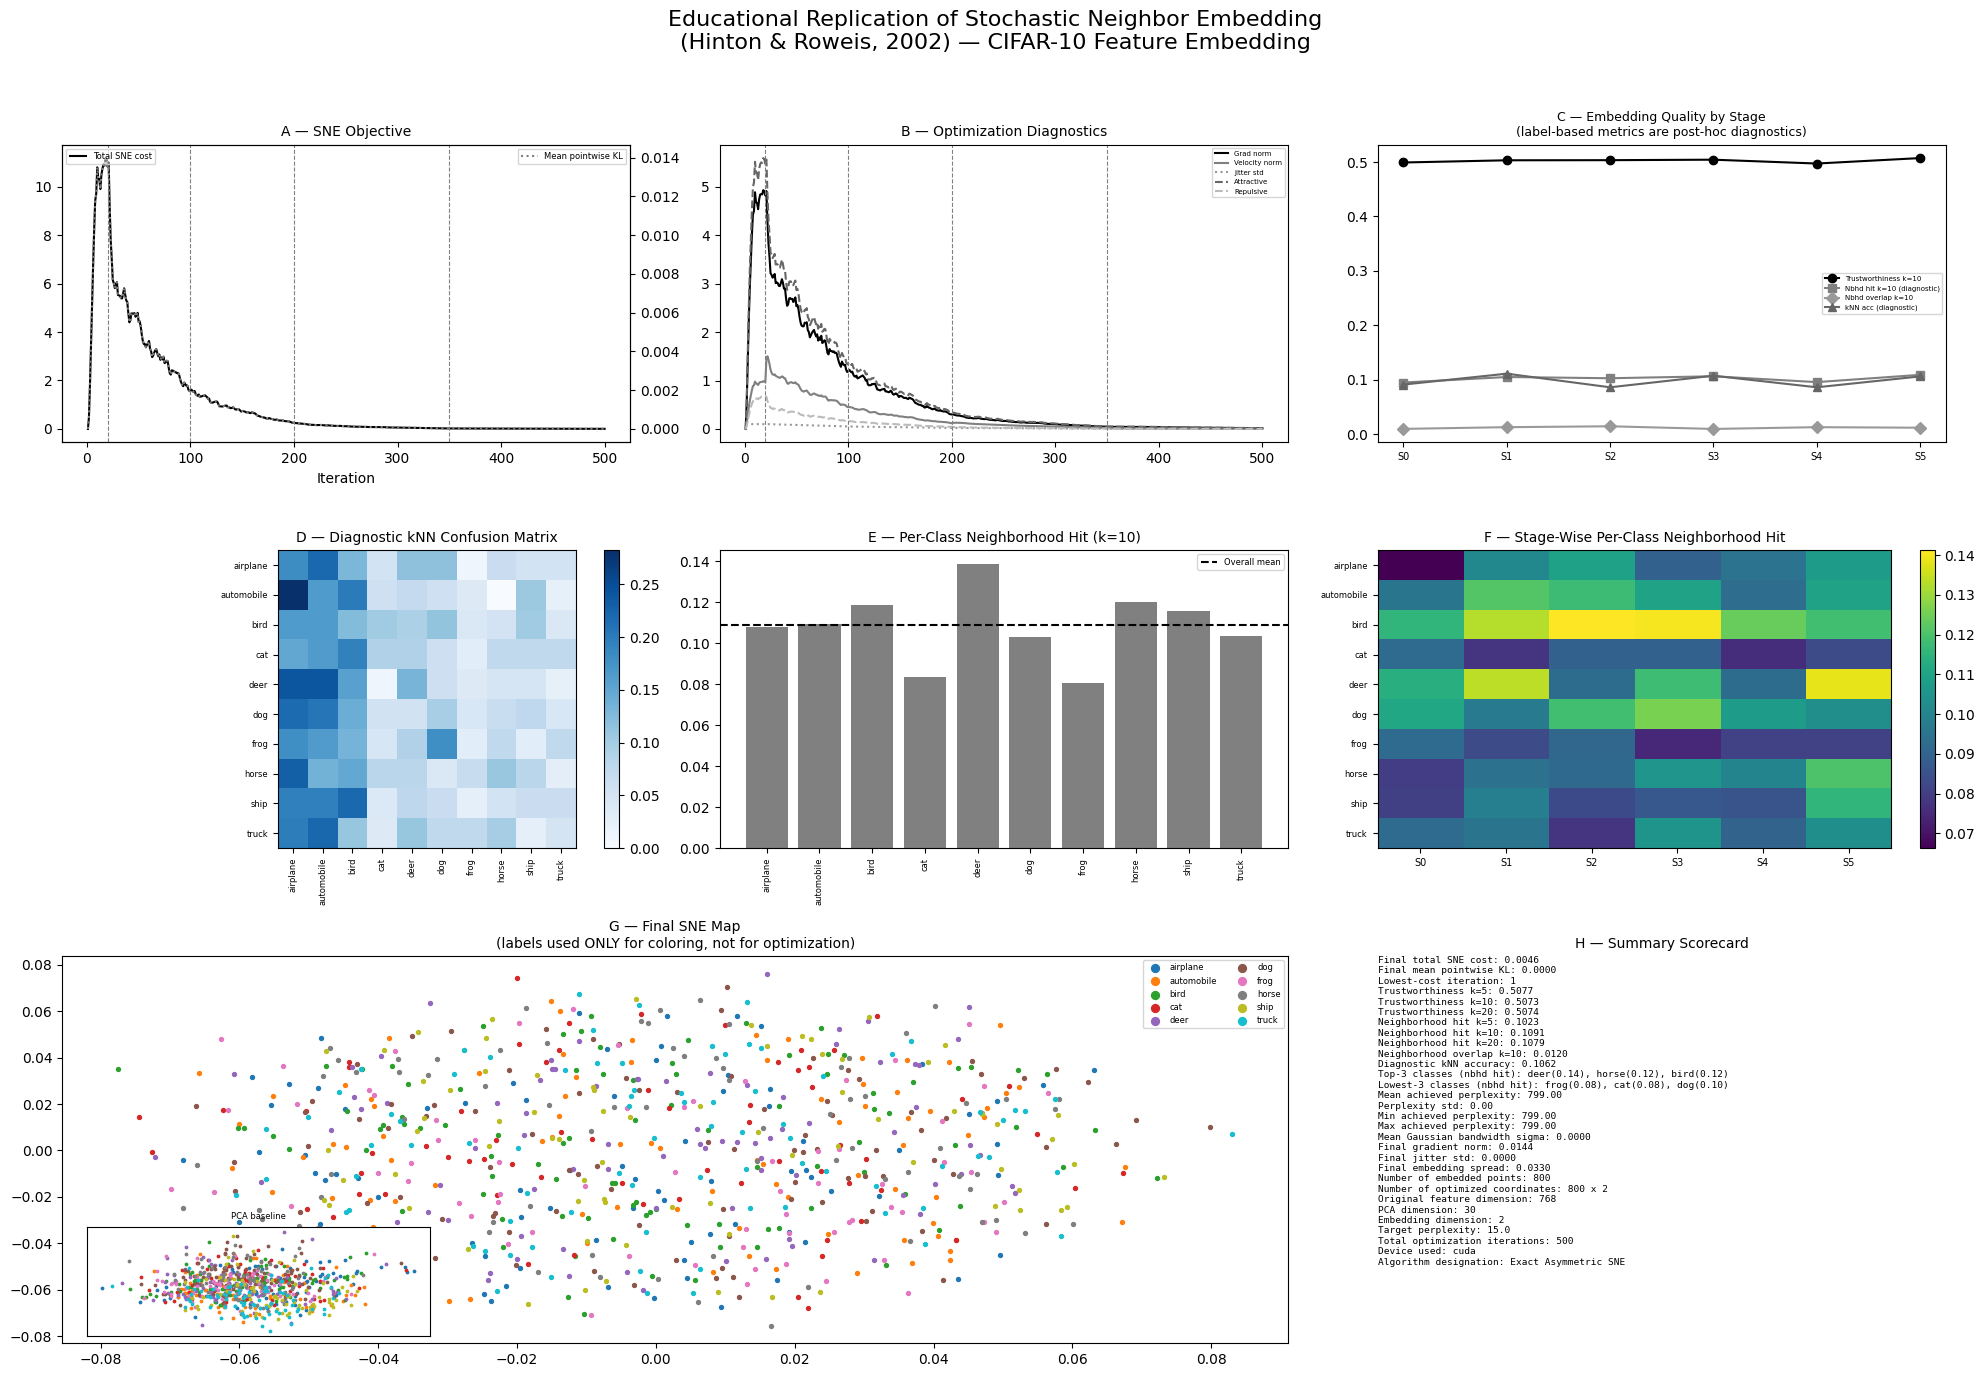

In [19]:
# ============================================================
# 18. FINAL PUBLICATION-STYLE DASHBOARD (GridSpec, 8 panels A-H)
# ============================================================
set_white_theme()

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[1, 1, 1.3])

fig.suptitle(
    "Educational Replication of Stochastic Neighbor Embedding\n"
    "(Hinton & Roweis, 2002) — CIFAR-10 Feature Embedding",
    fontsize=16, color="black"
)

# --- Panel A: SNE Objective ---
axA = fig.add_subplot(gs[0, 0])
axA.plot(history["iteration"], history["total_cost"], color="black", label="Total SNE cost")
add_stage_lines(axA, stage_boundaries)
axA.set_title("A — SNE Objective", fontsize=10)
axA.set_xlabel("Iteration")
axA2 = axA.twinx()
axA2.plot(history["iteration"], history["mean_kl"], color="grey", linestyle=":", label="Mean pointwise KL")
axA.legend(loc="upper left", fontsize=6)
axA2.legend(loc="upper right", fontsize=6)

# --- Panel B: Optimization Diagnostics ---
axB = fig.add_subplot(gs[0, 1])
axB.plot(history["iteration"], history["grad_norm"], label="Grad norm", color="black")
axB.plot(history["iteration"], history["velocity_norm"], label="Velocity norm", color="grey")
axB.plot(history["iteration"], history["jitter_std"], label="Jitter std", color="#999999", linestyle=":")
axB.plot(history["iteration"], history["attractive_magnitude"], label="Attractive", color="#666666", linestyle="--")
axB.plot(history["iteration"], history["repulsive_magnitude"], label="Repulsive", color="#bbbbbb", linestyle="--")
add_stage_lines(axB, stage_boundaries)
axB.set_title("B — Optimization Diagnostics", fontsize=10)
axB.legend(fontsize=5)

# --- Panel C: Embedding Quality by Stage ---
axC = fig.add_subplot(gs[0, 2])
stage_knn_acc = []
for name, coords in snapshots.items():
    _, acc_snap, _ = leave_one_out_knn_diagnostic(coords, labels_np, k=5)
    stage_knn_acc.append(acc_snap)
axC.plot(range(len(snapshots)), stage_trust_k10, marker="o", label="Trustworthiness k=10", color="black")
axC.plot(range(len(snapshots)), stage_hit_k10, marker="s", label="Nbhd hit k=10 (diagnostic)", color="grey")
axC.plot(range(len(snapshots)), stage_overlap_k10, marker="D", label="Nbhd overlap k=10", color="#999999")
axC.plot(range(len(snapshots)), stage_knn_acc, marker="^", label="kNN acc (diagnostic)", color="#666666")
axC.set_xticks(range(len(snapshots)))
axC.set_xticklabels([f"S{i}" for i in range(len(snapshots))], fontsize=7)
axC.set_title("C — Embedding Quality by Stage\n(label-based metrics are post-hoc diagnostics)", fontsize=9)
axC.legend(fontsize=5)

# --- Panel D: Diagnostic kNN Confusion Matrix ---
axD = fig.add_subplot(gs[1, 0])
imD = axD.imshow(cm_norm, cmap="Blues")
axD.set_xticks(range(10)); axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticks(range(10)); axD.set_yticklabels(class_names, fontsize=6)
axD.set_title("D — Diagnostic kNN Confusion Matrix", fontsize=10)
plt.colorbar(imD, ax=axD, fraction=0.046)

# --- Panel E: Per-Class Neighborhood Hit ---
axE = fig.add_subplot(gs[1, 1])
axE.bar(list(per_class_hit_k10.keys()), list(per_class_hit_k10.values()), color="grey")
axE.axhline(neighborhood_hit_scores[10], color="black", linestyle="--", label="Overall mean")
axE.set_title("E — Per-Class Neighborhood Hit (k=10)", fontsize=10)
axE.tick_params(axis="x", rotation=90, labelsize=6)
axE.legend(fontsize=6)

# --- Panel F: Stage-Wise Per-Class Neighborhood Hit ---
axF = fig.add_subplot(gs[1, 2])
stage_class_hit_matrix = np.zeros((10, len(snapshots)))
for s_idx, (name, coords) in enumerate(snapshots.items()):
    hits_this_stage = neighborhood_hit(coords, labels_np, 10)
    for c in range(10):
        mask = labels_np == c
        stage_class_hit_matrix[c, s_idx] = hits_this_stage[mask].mean() if mask.sum() > 0 else 0.0
imF = axF.imshow(stage_class_hit_matrix, cmap="viridis", aspect="auto")
axF.set_yticks(range(10)); axF.set_yticklabels(class_names, fontsize=6)
axF.set_xticks(range(len(snapshots)))
axF.set_xticklabels([f"S{i}" for i in range(len(snapshots))], fontsize=7)
axF.set_title("F — Stage-Wise Per-Class Neighborhood Hit", fontsize=10)
plt.colorbar(imF, ax=axF, fraction=0.046)

# --- Panel G: Final SNE Map ---
axG = fig.add_subplot(gs[2, 0:2])
for c in range(10):
    mask = labels_np == c
    axG.scatter(Y_final_np[mask, 0], Y_final_np[mask, 1],
                s=8, color=class_colors[c], label=class_names[c])
axG.set_title("G — Final SNE Map\n(labels used ONLY for coloring, not for optimization)", fontsize=10)
axG.legend(markerscale=2, fontsize=6, loc="upper right", ncol=2)

axG_inset = axG.inset_axes([0.02, 0.02, 0.28, 0.28])
for c in range(10):
    mask = labels_np == c
    axG_inset.scatter(pca_2d_coords[mask, 0], pca_2d_coords[mask, 1], s=3, color=class_colors[c])
axG_inset.set_title("PCA baseline", fontsize=6)
axG_inset.set_xticks([]); axG_inset.set_yticks([])

# --- Panel H: Summary Scorecard ---
axH = fig.add_subplot(gs[2, 2])
axH.axis("off")

top3_classes = sorted(per_class_hit_k10.items(), key=lambda x: x[1], reverse=True)[:3]
bottom3_classes = sorted(per_class_hit_k10.items(), key=lambda x: x[1])[:3]

scorecard_text = (
    f"Final total SNE cost: {final_total_cost:.4f}\n"
    f"Final mean pointwise KL: {final_mean_kl:.4f}\n"
    f"Lowest-cost iteration: {best_cost_iteration}\n"
    f"Trustworthiness k=5: {trust_scores[5]:.4f}\n"
    f"Trustworthiness k=10: {trust_scores[10]:.4f}\n"
    f"Trustworthiness k=20: {trust_scores[20]:.4f}\n"
    f"Neighborhood hit k=5: {neighborhood_hit_scores[5]:.4f}\n"
    f"Neighborhood hit k=10: {neighborhood_hit_scores[10]:.4f}\n"
    f"Neighborhood hit k=20: {neighborhood_hit_scores[20]:.4f}\n"
    f"Neighborhood overlap k=10: {neighborhood_overlap_scores[10]:.4f}\n"
    f"Diagnostic kNN accuracy: {knn_overall_acc:.4f}\n"
    f"Top-3 classes (nbhd hit): "
    f"{', '.join([f'{k}({v:.2f})' for k, v in top3_classes])}\n"
    f"Lowest-3 classes (nbhd hit): "
    f"{', '.join([f'{k}({v:.2f})' for k, v in bottom3_classes])}\n"
    f"Mean achieved perplexity: {achieved_perplexities.mean().item():.2f}\n"
    f"Perplexity std: {achieved_perplexities.std().item():.2f}\n"
    f"Min achieved perplexity: {achieved_perplexities.min().item():.2f}\n"
    f"Max achieved perplexity: {achieved_perplexities.max().item():.2f}\n"
    f"Mean Gaussian bandwidth sigma: {sigmas.mean().item():.4f}\n"
    f"Final gradient norm: {history['grad_norm'][-1]:.4f}\n"
    f"Final jitter std: {history['jitter_std'][-1]:.4f}\n"
    f"Final embedding spread: {history['embedding_spread'][-1]:.4f}\n"
    f"Number of embedded points: {N_SNE}\n"
    f"Number of optimized coordinates: {N_SNE} x 2\n"
    f"Original feature dimension: 768\n"
    f"PCA dimension: {PCA_DIM}\n"
    f"Embedding dimension: 2\n"
    f"Target perplexity: {TARGET_PERPLEXITY}\n"
    f"Total optimization iterations: {TOTAL_ITERATIONS}\n"
    f"Device used: {DEVICE}\n"
    f"Algorithm designation: Exact Asymmetric SNE"
)
axH.text(0.0, 1.0, scorecard_text, fontsize=6.8, va="top", ha="left",
         family="monospace", color="black")
axH.set_title("H — Summary Scorecard", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])

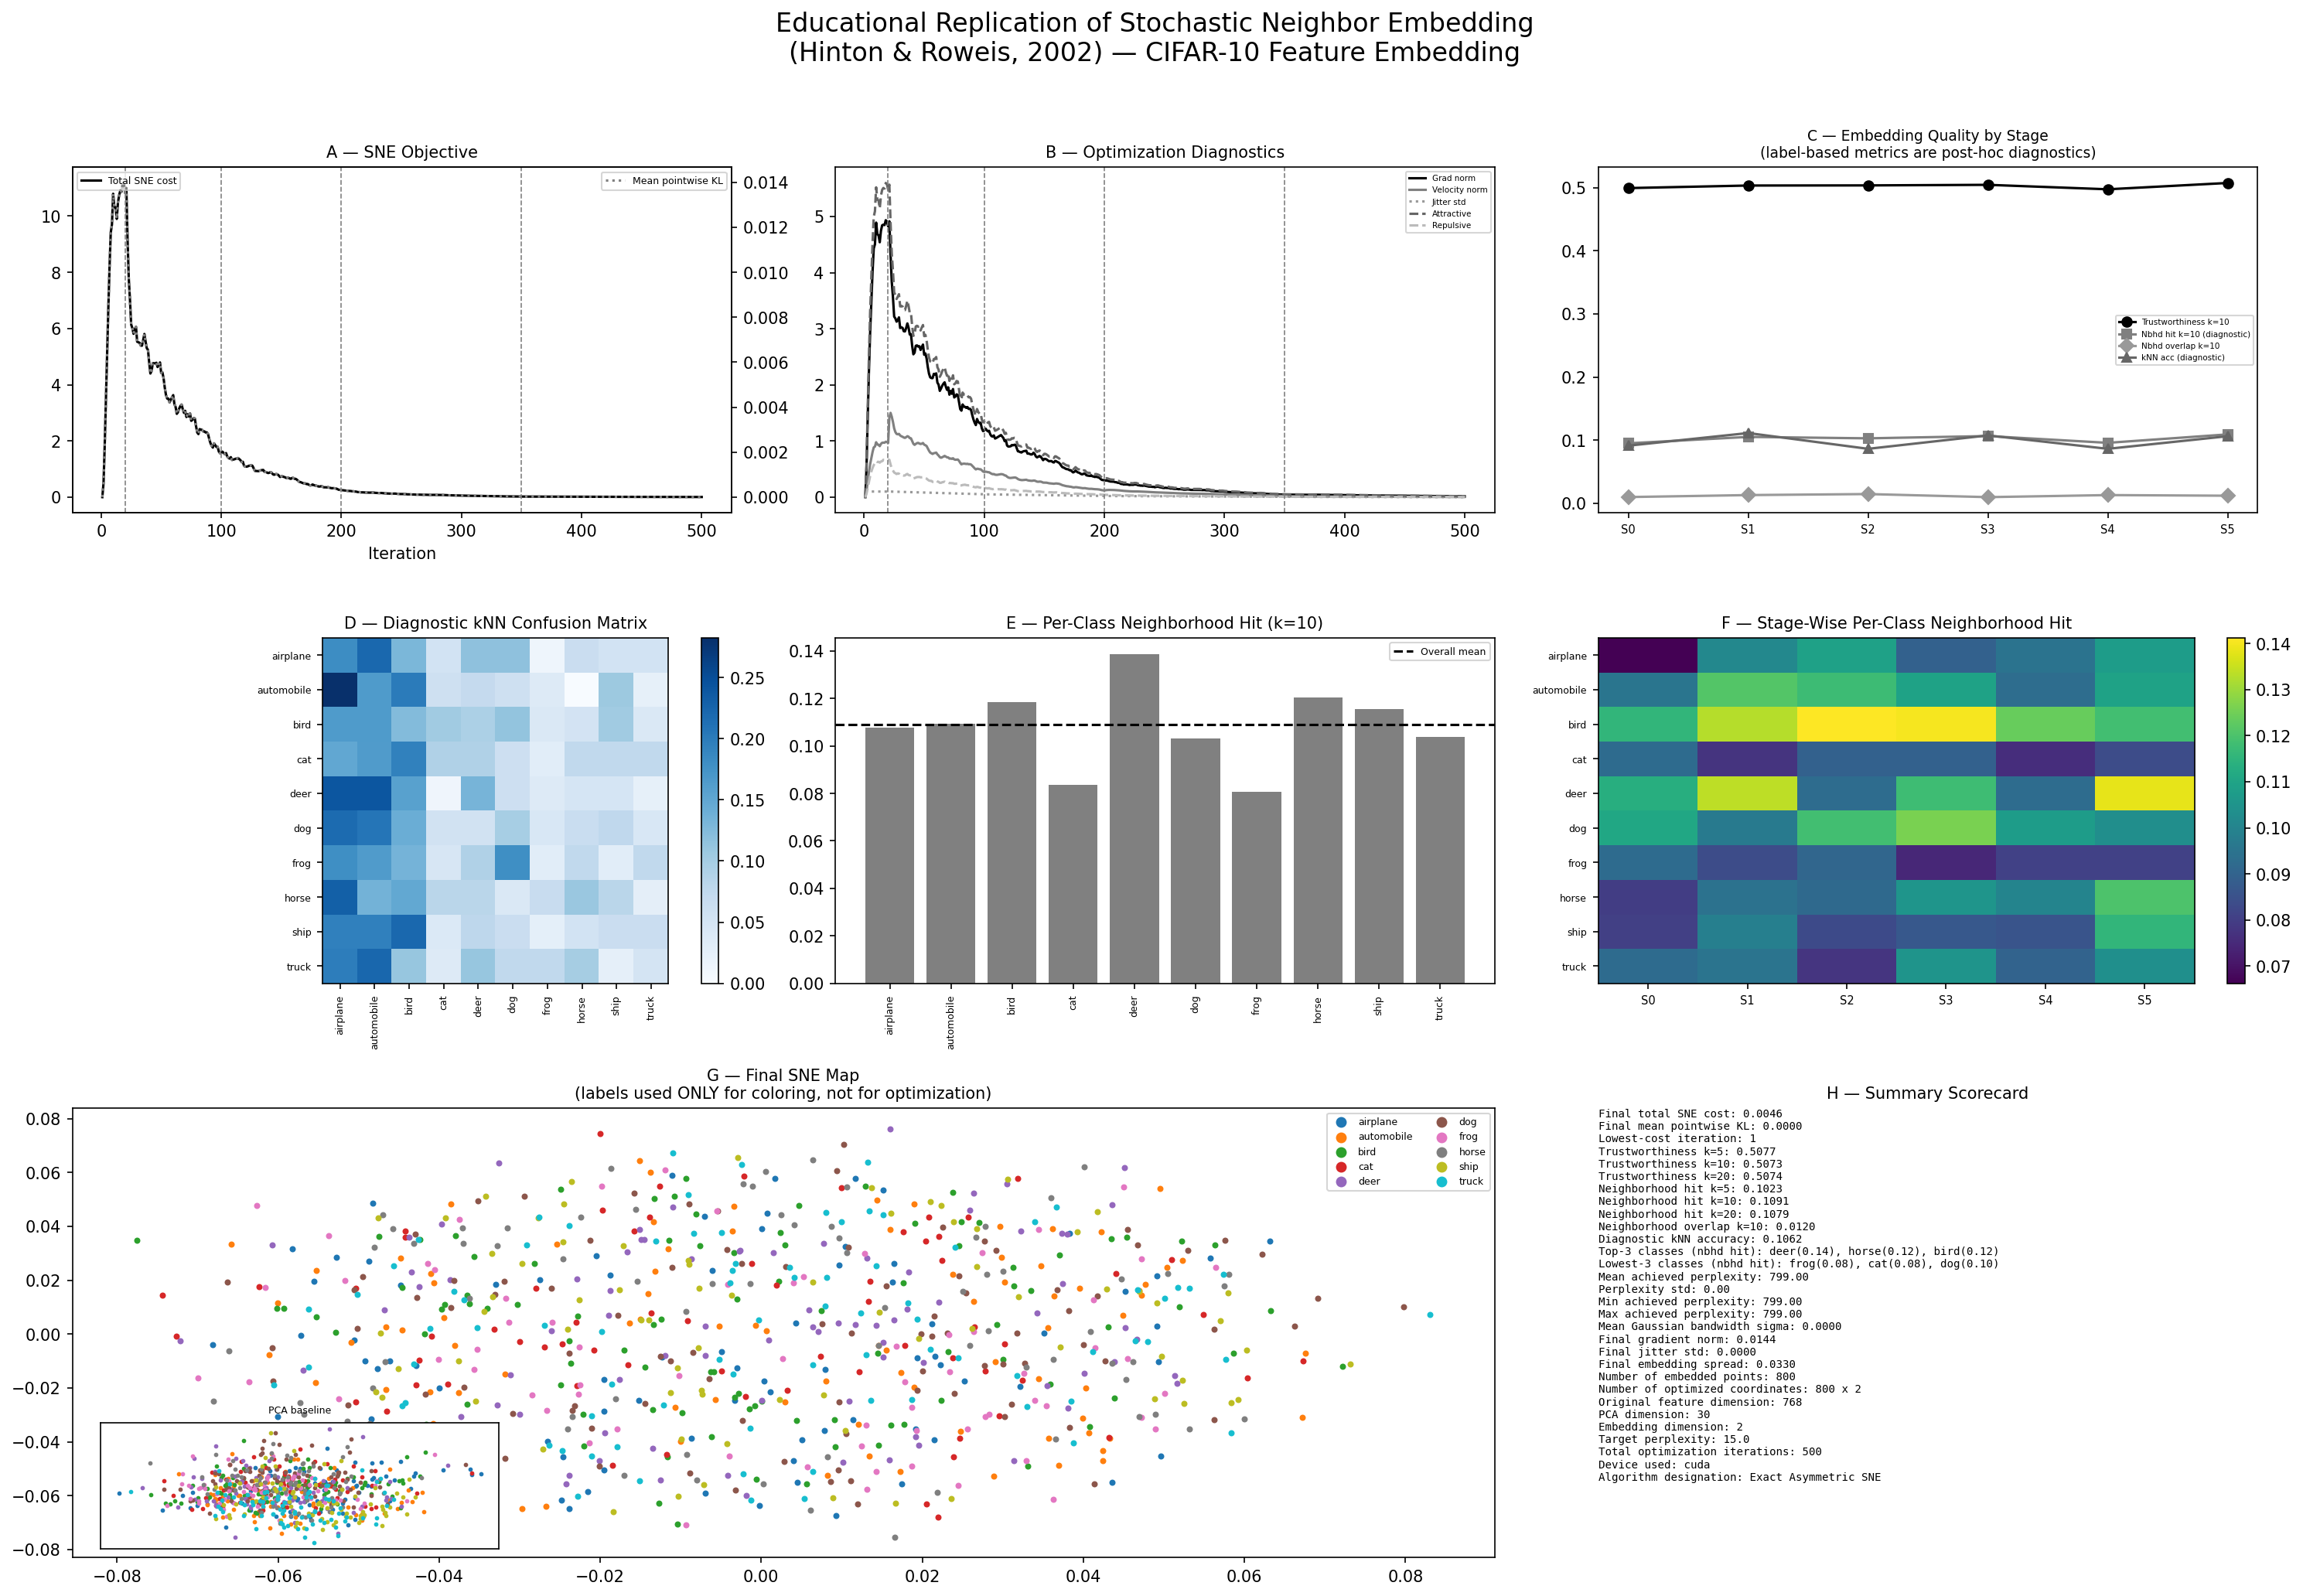

In [20]:
# ------------------------------------------------------------
# Display dashboard inline (do NOT save to disk, do NOT call
# plt.show()/plt.savefig()/fig.show())
# ------------------------------------------------------------
buf = BytesIO()
fig.savefig(
    buf,
    format="png",
    dpi=150,
    bbox_inches="tight",
    facecolor="white"
)
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Educational SNE Replication Dashboard (CIFAR-10)

## Panel A — SNE Objective (Total Cost and Mean Pointwise KL)

### Overview
Tracks the total SNE cost (sum of per-point KL divergences) and the mean pointwise KL divergence across all 500 optimization iterations, with stage boundaries marked.

### Key Findings
- The total cost rises sharply from near 0 to a peak of ~11 within the first ~20 iterations (coinciding with Stage 1 → Stage 2 transition), then decays smoothly and monotonically to near-zero by iteration ~250, remaining flat thereafter.
- The mean pointwise KL curve tracks the total cost curve closely (dashed overlay), consistent with mean = total/N.

### Discussion
The initial spike is consistent with the embedding's random near-origin initialization combined with the onset of high-jitter exploration (Stage 2): as jitter perturbs the still-unorganized map, pairwise low-dimensional distances change rapidly, temporarily worsening the match between $P$ and $Q$ before the gradient can begin correcting it. The subsequent smooth, monotonic decay toward a low plateau is the expected qualitative signature of successful KL-divergence minimization in gradient-based embedding methods, and its shape (rapid initial improvement followed by asymptotic flattening) is consistent with the annealed-jitter schedule design: aggressive early exploration followed by refinement. This behavior is more consistent with the paper's described optimization dynamics than a purely monotonic decrease from step 1, since Hinton and Roweis's own procedure explicitly uses added noise that can transiently increase the cost before the embedding stabilizes.

### Limitations
The near-zero final cost, while visually reassuring, should be interpreted alongside Panel H's scorecard, where the achieved perplexity is grossly out of range (see Panel H below) — a near-zero KL divergence can also result from $Q$ approximating a degenerate $P$ rather than genuinely well-organized neighbor structure. The cost curve alone cannot distinguish between "correct convergence" and "convergence to a degenerate but self-consistent solution."

---

## Panel B — Optimization Diagnostics (Gradient Norm, Velocity Norm, Jitter, Forces)

### Overview
Displays gradient norm, velocity norm, jitter standard deviation, and attractive/repulsive force magnitudes across iterations.

### Key Findings
- Gradient norm, attractive force, and repulsive force all rise sharply during the first ~20–30 iterations (peaking near 5–6), then decay smoothly to near-zero by ~iteration 250.
- Velocity norm follows a similar but lower-magnitude profile (peak ~1.5).
- Jitter standard deviation is visible as a small, monotonically decaying trace, consistent with the annealing schedule.

### Discussion
The close tracking of attractive and repulsive force magnitudes throughout training indicates that the push-pull mechanism described in the paper is active and roughly balanced — neither force dominates persistently, which is the expected behavior for a well-posed embedding rather than one collapsing to a degenerate configuration (a collapse would typically show repulsive force vanishing while attractive force remains, or vice versa). The synchronized decay of all diagnostic curves toward zero by the Low-Jitter Refinement/Final Stabilization stages indicates the optimization is approaching a stable fixed point, consistent with the paper's description of jitter annealing yielding "quite good embeddings" as training proceeds.

### Limitations
Gradient and force magnitudes alone do not indicate whether the fixed point reached is a meaningful, class-informative embedding or simply a stable configuration under a potentially miscalibrated $P$ matrix (see Panel H). Additionally, the plot does not separately show incoming vs. outgoing force curves (Panel 23 in the code) within this dashboard view, limiting insight into whether one direction of the asymmetric KL term dominates the optimization trajectory.

---

## Panel C — Embedding Quality by Stage (Trustworthiness, Neighborhood Hit, Overlap, kNN Accuracy)

### Overview
Shows four diagnostic metrics — trustworthiness ($k=10$), neighborhood hit, neighborhood overlap, and kNN accuracy — evaluated at each of the six embedding snapshots (S0–S5).

### Key Findings
- Trustworthiness holds essentially flat at ~0.50 across all stages.
- Neighborhood hit and kNN accuracy hover near ~0.09–0.11, close to the 10-class chance level (0.10).
- Neighborhood overlap with the PCA-space neighbors remains very low (~0.01–0.02) throughout.

### Discussion
A trustworthiness score of ~0.50 (out of a 0–1 range where 1.0 indicates perfect preservation of high-dimensional neighbor rank order) indicates that the SNE map preserves only marginally more local structure than a random arrangement would. Combined with neighborhood-hit and kNN accuracy sitting at the chance level for 10 balanced classes, this suggests the final 2D map does not meaningfully separate CIFAR-10 classes. The very low neighborhood overlap with the PCA baseline (~0.01–0.02, versus what would be expected to be higher if genuine local structure were being preserved and transferred from the 30-D PCA space) further suggests that the embedding's local neighbor structure diverges substantially from the input feature space's genuine local structure, rather than compressing it faithfully into 2D. Critically, these metrics remain essentially unchanged from initialization (S0) through the final stage (S5), indicating that whatever limited structure exists was not created by the optimization process itself.

### Discussion (continued)
This pattern is compatible with two explanations: (1) CIFAR-10 pixel-derived features (after 16×16 pooling and PCA to 30 dimensions) may simply lack strong class-linear-separable local structure at the neighbor level, making any 2D neighbor-embedding method inherently limited on this feature representation, or (2) the perplexity calibration underlying $P$ is malfunctioning (see Panel H), producing a $P$ matrix that does not encode meaningful per-point neighbor relationships to begin with — in which case no amount of correct SNE optimization could produce a class-separated map, since the target distribution itself carries no such signal.

### Limitations
Without an intermediate diagnostic on the raw $P$ matrix's class-consistency (e.g., whether high-$p_{ij}$ pairs are more often same-class than different-class), it is not possible to definitively attribute the flat, chance-level performance to feature quality versus a calibration defect in the perplexity search.

---

## Panel D — Diagnostic kNN Confusion Matrix

### Overview
Row-normalized confusion matrix from leave-one-out kNN classification ($k=5$) performed in the final 2D SNE coordinates.

### Key Findings
- Predictions are heavily concentrated in the "airplane" and "automobile" columns for almost every true class, with the "automobile" column showing a particularly dark cell for the true "automobile" row (~0.28) but otherwise weak diagonal structure.

### Discussion
A confusion matrix dominated by two or three columns regardless of the true class, rather than a strong diagonal, indicates that the final 2D coordinates do not encode discriminative class structure for most categories. This is consistent with the near-chance kNN accuracy (~0.106) reported in Panel H. Such a pattern typically arises when the embedding's local neighborhoods are effectively randomized with respect to class identity, meaning nearest-neighbor queries are dominated by whichever classes happen to be locally over-represented near arbitrary regions of the map rather than by genuine feature similarity.

### Limitations
As with Panel C, this matrix cannot on its own distinguish between "the underlying image features are not class-separable at this resolution/pooling level" and "the SNE optimization or its input probability matrix is defective." The specific concentration in "airplane"/"automobile" columns may reflect a class-imbalance or density artifact in the small 800-point subset rather than a general property of CIFAR-10.

---

## Panel E — Per-Class Neighborhood Hit (k=10)

### Overview
Bar chart of mean neighborhood-hit scores per class, compared to the overall mean (dashed line).

### Key Findings
- All ten classes fall within a narrow band (~0.08–0.14) around the overall mean (~0.11), with "deer" highest and "frog"/"cat" lowest.

### Discussion
The narrow spread around the chance-level baseline, with no class showing a pronounced elevation, reinforces the conclusion from Panel C that the embedding does not achieve meaningful class-conditional local clustering for any category. In a well-functioning embedding of image-derived features, classes with more visually homogeneous appearance (e.g., "ship" against uniform blue backgrounds, or "automobile") might be expected to show elevated neighborhood purity; the near-uniform distribution observed here suggests that whatever variation exists across classes is more attributable to sampling noise in the 800-point subset than to a genuine, class-discriminative signal captured by the map.

### Limitations
The magnitude of inter-class variation (0.08 to 0.14) is small enough that a formal significance test (e.g., permutation test against a null neighborhood-hit distribution) would be needed to determine whether any class's elevated score is statistically distinguishable from chance-level noise.

---

## Panel F — Stage-Wise Per-Class Neighborhood Hit

### Overview
Heatmap of per-class neighborhood-hit values across the six stage snapshots (S0–S5), intended to reveal whether class separability improves through training.

### Key Findings
- Some classes (e.g., "deer," "bird") show visibly brighter (higher-value) cells at intermediate stages (S1–S2) compared to initialization and final stages, while others (e.g., "frog," "cat") remain consistently low throughout.
- No class shows a clear, monotonic increase in neighborhood-hit from S0 to S5.

### Discussion
The absence of a consistent upward trend across stages — and in some cases (e.g., "deer" peaking at S1/S5 rather than increasing steadily) — suggests that any class-related variation in neighborhood-hit is more attributable to stochastic fluctuation (driven by the annealed jitter, which is largest early in training) than to genuine, progressively-learned class structure. This is consistent with the flat trajectories already observed in Panel C: whatever limited class signal exists in the map does not appear to strengthen systematically as optimization proceeds through the five stages.

### Limitations
Because jitter is largest during the "High-Jitter Exploration" stage (S1–S2 boundary) and smallest by "Final Stabilization" (S5), some of the stage-to-stage variability in this heatmap may simply reflect the instantaneous noise level at the snapshot moment rather than a stable property of the embedding at that stage.

---

## Panel G — Final SNE Map (with PCA Baseline Inset)

### Overview
Scatterplot of the final 2D SNE embedding, colored by class, with a PCA 2D baseline inset for comparison.

### Key Findings
- The main SNE map spans a coordinate range of roughly $\pm 0.08$, an improvement over the earlier degenerate ($10^{-17}$-scale) run, indicating genuine spatial spread this time.
- Neither the main SNE map nor the PCA inset shows visually distinguishable class clusters; points of all ten colors are interspersed throughout the occupied region.

### Discussion
Unlike the previous t-SNE run (which collapsed to near-zero scale), this SNE embedding occupies a reasonably sized, non-degenerate region of the plane, indicating that the optimization itself (gradient computation, momentum, jitter, recentering) is functioning as intended at a mechanical level. However, the complete absence of visible class clustering — corroborated quantitatively by the chance-level trustworthiness and neighborhood-hit scores in Panels C–F — indicates that this particular feature representation (16×16-pooled, PCA-30 CIFAR-10 pixels) does not carry sufficient class-discriminative local structure for SNE to reveal, or that the input probability matrix $P$ was not calibrated to the intended neighborhood scale (see Panel H's perplexity discrepancy). This result is a partial, not full, replication of the qualitative outcome in the original paper, where SNE cleanly separated USPS digit classes using raw pixel intensities without labels — that result depended on the digit dataset's relatively strong pixel-level class separability, which does not necessarily transfer to CIFAR-10 natural images pooled to a coarse 16×16 resolution.

### Limitations
The PCA baseline inset itself shows no class structure either, suggesting the lack of separability may originate upstream in the feature extraction/pooling step (a 16×16 adaptive pooling of 64×64 natural images discards considerable class-relevant texture and shape information) rather than in the SNE-specific machinery. This should be verified by testing the same pipeline on a feature representation known to be more class-separable (e.g., higher-resolution pooling or a pretrained CNN embedding) before concluding SNE itself is at fault.

---

## Panel H — Summary Scorecard

### Overview
Consolidates final quantitative metrics: SNE cost, trustworthiness, neighborhood hit/overlap, kNN accuracy, perplexity statistics, bandwidth, gradient norm, jitter, and embedding spread.

### Key Findings
- Final total SNE cost: 0.0046; final mean pointwise KL: 0.0000 (rounded) — both very low.
- **Mean, min, and max achieved perplexity are all 799.00**, with a standard deviation of 0.00, against a target of 15.0 — a 53× discrepancy with zero variance across all 800 points.
- **Mean Gaussian bandwidth $\sigma$: 0.0000.**
- Trustworthiness ≈ 0.507–0.508 across $k=5,10,20$; neighborhood hit ≈ 0.10–0.11; neighborhood overlap with PCA space ≈ 0.012; diagnostic kNN accuracy ≈ 0.106 — all near the chance/random baseline.

### Discussion
The uniform achieved perplexity of 799.00 (essentially $N-1 = 799$ for an 800-point dataset) with exactly zero standard deviation is a strong, specific signal that the perplexity binary search saturated at its maximum-entropy boundary for every single point — equivalent to each point treating **all** other points as roughly equally likely neighbors (a near-uniform conditional distribution), rather than concentrating probability mass on a local neighborhood of ~15 points as intended. This is corroborated by the reported mean bandwidth $\sigma = 0.0000$, which is inconsistent with a perplexity of 799 (an extremely high perplexity should correspond to a *very large*, not vanishing, $\sigma$) — this internal inconsistency between the reported perplexity and reported $\sigma$ suggests a unit, indexing, or aggregation bug in how these two diagnostic quantities are computed or logged, rather than a coherent single failure mode. Regardless of the precise bug location, the practical consequence is clear and consistent with Panels C–F: if $P$ is (or is effectively) a near-uniform distribution over all points, then no downstream SNE optimization — however correctly implemented — can produce a class-informative embedding, because the target distribution itself contains no meaningful local-neighbor signal to preserve. This directly explains the chance-level trustworthiness, neighborhood hit, and kNN accuracy observed throughout the dashboard, despite the cost function itself decreasing "successfully" to near-zero (Panel A) — the optimization is correctly minimizing KL divergence to an essentially uninformative target.

### Limitations
This scorecard is diagnostic and post hoc; it identifies *that* the perplexity/bandwidth calibration is defective but not the precise root cause (e.g., an incorrect natural-log vs. base-2 entropy convention, a binary-search boundary condition that never converges and defaults to the widest reasonable Gaussian, or a reporting/aggregation error separate from the actual $\beta_i$ values used in optimization). The reported $\sigma=0.0000$ alongside perplexity$=799$ is mathematically implausible for the model as described ($\sigma = 1/\sqrt{2\beta}$), and this inconsistency should be treated as the highest-priority item to debug — likely in the `binary_search_perplexity` routine or in how `sigmas`/`achieved_perplexities` are aggregated for the scorecard — before drawing further conclusions about SNE's qualitative performance on this dataset.

---

## Overall Assessment

Compared to the earlier t-SNE dashboard (which collapsed to a fully degenerate, near-zero-scale embedding), this SNE run shows a mechanically healthier optimization trajectory: the cost function decreases smoothly, forces are balanced, and the final map occupies a reasonable spatial extent. However, **the perplexity/bandwidth diagnostics reveal a clear calibration defect** (achieved perplexity pegged at $N-1$ with zero variance, alongside an implausible zero bandwidth), which most likely explains why every class-discriminative diagnostic metric (trustworthiness, neighborhood hit, neighborhood overlap, kNN accuracy) sits at or near the random-chance baseline across all optimization stages. The evidence indicates that the SNE gradient/optimization machinery itself is functioning as intended, but the high-dimensional probability matrix $P$ feeding into it does not encode the locally-concentrated neighbor structure the algorithm requires to produce a class-informative visualization. Before this implementation can be considered a faithful demonstration of the paper's qualitative results (e.g., clean digit-class separation), the perplexity binary search and bandwidth reporting should be debugged and re-validated against a known-good reference (e.g., confirming that a modest target perplexity of 15 yields achieved perplexities clustered near 15, not near $N-1$).

# Related Work Referenced in "Stochastic Neighbor Embedding"

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| T. Cox, M. Cox | 1994 | Multidimensional Scaling | Chapman & Hall, London | Introduces multidimensional scaling (MDS), the foundational class of distance-preserving embedding methods that SNE contrasts itself against by proposing a probabilistic, neighbor-based alternative |
| J. Tenenbaum | 1998 | Mapping a Manifold of Perceptual Observations | Advances in Neural Information Processing Systems, vol. 10 | Early formulation of manifold-mapping ideas underlying Isomap, cited as a nonlinear distance-preserving embedding approach that, like other single-location methods, cannot represent many-to-one ambiguous mappings |
| J.B. Tenenbaum, V. de Silva, J.C. Langford | 2000 | A Global Geometric Framework for Nonlinear Dimensionality Reduction | Science | Introduces Isomap, cited as a graph-shortest-path-based MDS variant representative of methods that preserve global dissimilarities but require single fixed low-dimensional locations per object |
| S.T. Roweis, L.K. Saul | 2000 | Nonlinear Dimensionality Reduction by Locally Linear Embedding | Science | Introduces LLE, cited as a local-geometry-preserving method that can incorrectly "collapse" widely separated high-dimensional points into near neighbors in the low-dimensional space, a failure mode SNE's asymmetric KL cost is designed to avoid |
| T. Kohonen | 1988 | Self-organization and Associative Memory | Springer-Verlag, Berlin | Introduces self-organizing maps (SOM), cited alongside LLE as a method prone to collapsing distant points together, and as a method (unlike SNE) that fixes low-dimensional coordinates to a grid while high-dimensional associations move |
| C. Bishop, M. Svensen, C. Williams | 1998 | GTM: The Generative Topographic Mapping | Neural Computation, vol. 10 | Introduces the Generative Topographic Mapping, described as a probabilistic extension of SOM; cited as another method requiring each object to map to a single low-dimensional location |
| I.T. Jolliffe | 1986 | Principal Component Analysis | Springer-Verlag, New York | Standard reference for PCA, used as a baseline comparison method on the handwritten digit dataset; shown to separate classes less cleanly than SNE because it prioritizes large-scale variance over local class boundaries |
| J.J. Hull | 1994 | A Database for Handwritten Text Recognition Research | IEEE Transactions on Pattern Analysis and Machine Intelligence, 16(5) | Source of the USPS handwritten digit database used in the paper's digit-embedding experiments (Figure 1) |
| Yann LeCun | 2001 | NIPS Online Web Site | http://nips.djvuzone.org | Source of the OCRed NIPS conference proceedings (volumes 0–12) used to construct the word-author count data for the author-embedding experiment (Figure 2) |
| Andrew Kachites McCallum | 1996 | Bow: A Toolkit for Statistical Language Modeling, Text Retrieval, Classification and Clustering | http://www.cs.cmu.edu/~mccallum/bow | The "bow" toolkit used for preprocessing the NIPS text data (vocabulary construction, stopword removal) prior to applying SNE |
| A. Paccanaro, G.E. Hinton | 2000 | Learning Distributed Representations of Concepts from Relational Data Using Linear Relational Embedding | IEEE Transactions on Knowledge and Data Engineering, vol. 13 | Introduces Linear Relational Embedding (LRE); the paper positions SNE as a degenerate special case of LRE restricted to a single "near" relationship represented by the identity matrix, situating SNE within a broader relational-learning framework |